# HCA Healthcare Coding Challenge - Notebook 1: EDA and Feature Generation

---

# Overview of Workflow

## 1. Data Cleaning and Standardization

The notebook begins by cleaning and standardizing the visit and vital sign data. This includes:

- Checking for and converting inconsistent temperature units (Fahrenheit to Celsius)
- Correcting likely systolic/diastolic blood pressure swaps
- Flagging physiologically implausible values
- Standardizing timestamps and temporal calculations
- Filtering vitals to only those observed before the prediction time

These steps improve data quality while preserving potentially informative missingness and variability patterns commonly encountered in EHR data.

---

## 2. Cohort Construction

A prediction cohort is constructed using the assignment requirement that patients are scored at the first 6AM occurring during admission.

The cohort generation logic:
- Calculates the first eligible 6AM scoring time
- Removes visits without a valid scoring window
- Excludes patients who died during the encounter
- Restricts all feature generation to data available before the prediction timestamp

The target variable is whether the patient is readmitted within 30 days following discharge.

---

## 3. Feature Engineering

Visit-level features are generated from demographics, visit history, and longitudinal vital sign trajectories.

Feature categories include:

### Demographic / Visit Features
- Age at prediction time
- Time admitted before prediction
- ED-to-admission duration
- Admission timing features (hour/day/weekend/night)

### Historical Utilization Features
- Prior visit counts
- Prior 30-day and 180-day utilization
- Prior readmission indicators
- Time since previous discharge

### Vital Sign Summary Features
For heart rate, blood pressure, temperature, MAP, pulse pressure, and shock index:
- Mean, median, min, max
- Standard deviation and coefficient of variation
- Quantiles and interquartile range
- Temporal deltas and slopes
- First-half vs second-half trends

These features summarize both physiologic severity and physiologic instability prior to prediction.

---

## 4. Exploratory Data Analysis (EDA)

EDA is performed at the visit level to better understand:
- Class imbalance
- Missingness patterns
- Demographic distributions
- Prior utilization patterns
- Vital sign distributions and trends
- Feature-target relationships
- Feature correlations and redundancy

Correlation analysis is also used to identify highly redundant features prior to modeling.

---

# Outputs

The final output of this notebook is a cleaned, feature-engineered cohort (as a .csv file) suitable for:
- Machine learning model development
- Threshold optimization
- Fairness and equity analysis
- Model interpretation and SHAP analysis

## Imports

In [1]:
# Imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


# Global settings

timestamp = datetime.now().strftime("%d%m%Y")

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Data configuration
Files downloaded to cwd from [kaggle](https://www.kaggle.com/datasets/7290f7b5b8292a5caf1e2bd15c2ea409c9e51f842c0f9aa1a888cbe0fa61c961?resource=download)

In [2]:
visits_path = PROJECT_ROOT / "visits.csv"
vitals_path = PROJECT_ROOT / "vitals.csv"

## Load Data

In [3]:
visits_raw = pd.read_csv(visits_path, parse_dates=["birth_date","ed_arrival","admission","discharge"])
vitals_raw = pd.read_csv(vitals_path, parse_dates=["timestamp"])
print(f"Visits shape: {visits_raw.shape}, Vitals shape: {vitals_raw.shape}")
display(visits_raw.head())
display(vitals_raw.head())

Visits shape: (5583, 11), Vitals shape: (743097, 7)


,first_name,last_name,sex,birth_date,patient_id,ed_arrival,admission,discharge,visit_id,will_readmit,died
0,Kristie,Jones,female,1948-01-05 18:33:46.074221,bad7d350-987a-418c-9ee3-adb1ccefbe17,2012-09-03 16:25:00,2012-09-04 02:25:00,2012-09-12 02:25:00,08f2d881-859a-467a-a468-d93bddb6d84e,False,False
1,Courtney,Green,female,1964-09-25 18:33:46.074221,fbb3c986-37ad-4c02-9204-fea258ff2baa,2012-04-12 16:57:00,2012-04-13 07:57:00,2012-04-19 07:57:00,bd53349f-82bc-4ee8-8487-8da73ca9fa42,False,False
2,Michael,Webb,male,1983-05-24 18:33:46.074221,8dfeae96-e8b2-4ad4-a39c-58e9b9957dcf,2012-04-09 19:54:00,2012-04-10 19:54:00,2012-04-18 19:54:00,24322347-62fc-4d2d-b472-c7eb1eca2357,False,False
3,Tony,Vaughn,male,1951-12-07 18:33:46.074221,33f4ffa4-7ea3-4f5b-a995-61177b6c618d,2012-02-01 04:27:00,2012-02-01 17:27:00,2012-02-08 17:27:00,5876df30-9544-4b7b-b07c-9c180303f69b,False,False
4,Danielle,Jones,female,1931-08-19 18:33:46.074221,4e1c1573-539b-4f20-8767-1abab51d473a,2012-02-28 09:18:00,2012-02-28 17:18:00,2012-03-07 17:18:00,e1bf2fc7-a22d-4aee-93bc-7f4d8af44b2c,False,False


,timestamp,patient_id,visit_id,heart_rate,systolic_bp,diastolic_bp,temperature
0,2012-09-03 16:46:00,bad7d350-987a-418c-9ee3-adb1ccefbe17,08f2d881-859a-467a-a468-d93bddb6d84e,70,111,86,37.6
1,2012-09-03 18:22:00,bad7d350-987a-418c-9ee3-adb1ccefbe17,08f2d881-859a-467a-a468-d93bddb6d84e,79,92,79,37.4
2,2012-09-03 18:27:00,bad7d350-987a-418c-9ee3-adb1ccefbe17,08f2d881-859a-467a-a468-d93bddb6d84e,55,84,102,37.5
3,2012-09-03 20:17:00,bad7d350-987a-418c-9ee3-adb1ccefbe17,08f2d881-859a-467a-a468-d93bddb6d84e,57,91,88,36.9
4,2012-09-03 21:17:00,bad7d350-987a-418c-9ee3-adb1ccefbe17,08f2d881-859a-467a-a468-d93bddb6d84e,83,107,106,37.2


## Clean visits table
Check demographics, compute lengths and first-score time, and build visit-history features:

### First Eligible 6AM Prediction Timestamp

This helper function determines the first valid 6AM scoring time during a patient's admission. The coding assignment specifies that patients should be scored every morning at 6AM (reoccurring) while they are hospitalized, so this function is used to identify the prediction timestamp for each encounter.

This prediction timestamp is later used to:
- Define cohort eligibility
- Restrict features to only data available prior to prediction
- Prevent temporal leakage from future information

Example:
- Admitted at `2012-01-01 02:00` → prediction time = `2012-01-01 06:00`
- Admitted at `2012-01-01 14:00` → prediction time = `2012-01-02 06:00`
- Discharged before first 6AM → excluded from modeling cohort

In [4]:
def first_score_time(admit, discharge):
    """
    Determine the first eligible 6AM prediction timestamp during admission.

    Rules:
    - Returns the same-day 6AM if admission occurs before 6AM
    - Otherwise returns the next-day 6AM
    - Returns pd.NaT if the patient is discharged before the
      first eligible 6AM
    - Returns pd.NaT for missing admission or discharge timestamps

    Parameters
    admit : pd.Timestamp
        Hospital admission timestamp.

    discharge : pd.Timestamp
        Hospital discharge timestamp.

    Returns
    pd.Timestamp or pd.NaT
        First valid 6AM prediction time during admission.
    """

    if pd.isna(admit) or pd.isna(discharge):
        return pd.NaT

    six_am = admit.normalize() + pd.Timedelta(hours=6)

    if admit <= six_am:
        first_6am = six_am
    else:
        first_6am = six_am + pd.Timedelta(days=1)

    if discharge > first_6am:
        return first_6am

    return pd.NaT

### Visit-Level Feature Engineering

This section generates visit-level features from admission, discharge, demographic, and historical utilization data.

The workflow begins by calculating basic encounter timing features such as:
- Length of stay
- Time from ED arrival to admission
- Time admitted before the first eligible 6AM prediction window

The first valid 6AM scoring timestamp is then calculated for each encounter. Patients who are discharged before reaching a valid 6AM scoring time are excluded from the modeling cohort.

Demographic and target features are also created, including:
- Age at prediction time (the patient’s age at the 6AM scoring timestamp)
- Binary 30-day readmission target
- Mortality indicator

Additional temporal admission features are engineered from ED arrival and admission timestamps. Since time-related variables are cyclical rather than linear (e.g., 11PM and 12AM are close together), sine/cosine cyclical encodings are created for:
- Hour of day
- Day of week

Binary indicators are also created for:
- Weekend admissions
- Nighttime admissions

Finally, historical utilization features are generated by sorting encounters chronologically within each patient. These features summarize prior healthcare utilization patterns and include:
- Prior visit counts
- Prior readmissions
- Time since previous discharge
- Prior 30-day and 90-day return indicators

The final `primary` cohort contains:
- Encounters reaching a valid first 6AM prediction window
- Patients discharged alive
- Only information available prior to prediction time

In [5]:
visits = visits_raw.copy()

# ---------------------------------------------------------------------
# Visit duration features
# ---------------------------------------------------------------------

visits["los_hours"] = (
    visits["discharge"] - visits["admission"]
).dt.total_seconds() / 3600

visits["ed_to_admit_hours"] = (
    visits["admission"] - visits["ed_arrival"]
).dt.total_seconds() / 3600

# ---------------------------------------------------------------------
# First eligible 6AM prediction timestamp
# ---------------------------------------------------------------------

visits["score_time"] = [
    first_score_time(a, d)
    for a, d in zip(visits["admission"], visits["discharge"])
]

# Eligible if patient reaches a valid 6AM scoring window
visits["eligible"] = visits["score_time"].notna().astype(int)

# Hours admitted before prediction
visits["time_to_score_hours"] = (
    visits["score_time"] - visits["admission"]
).dt.total_seconds() / 3600

# ---------------------------------------------------------------------
# Demographics / target
# ---------------------------------------------------------------------

# Age at prediction time
visits["age_at_prediction"] = (
    (visits["score_time"] - visits["birth_date"]).dt.total_seconds()
    / (365.25 * 24 * 3600)
).clip(lower=0)

# Binary target
visits["target"] = visits["will_readmit"].astype(int)

# Mortality indicator
visits["died_flag"] = visits["died"].astype(int)

# ---------------------------------------------------------------------
# Temporal admission features
# ---------------------------------------------------------------------

for prefix, col in [("arr", "ed_arrival"), ("adm", "admission")]:

    # Hour of day and day of week
    visits[f"{prefix}_hour"] = visits[col].dt.hour
    visits[f"{prefix}_dow"] = visits[col].dt.dayofweek

    # Cyclical encoding of hour
    visits[f"{prefix}_sin"] = np.sin(
        2 * np.pi * visits[f"{prefix}_hour"] / 24
    )

    visits[f"{prefix}_cos"] = np.cos(
        2 * np.pi * visits[f"{prefix}_hour"] / 24
    )

    # Cyclical encoding of day of week
    visits[f"{prefix}_dow_sin"] = np.sin(
        2 * np.pi * visits[f"{prefix}_dow"] / 7
    )

    visits[f"{prefix}_dow_cos"] = np.cos(
        2 * np.pi * visits[f"{prefix}_dow"] / 7
    )

# Weekend admission flag
visits["admit_weekend"] = (
    visits["adm_dow"].isin([5, 6]).astype(int)
)

# Night admission flag
visits["admit_night"] = (
    visits["adm_hour"].isin(
        list(range(22, 24)) + list(range(0, 6))
    ).astype(int)
)

# ---------------------------------------------------------------------
# Historical utilization features
# ---------------------------------------------------------------------

# Sort chronologically within patient
visits.sort_values(
    ["patient_id", "admission"],
    inplace=True,
)

grp = visits.groupby("patient_id", sort=False)

# Number of prior visits
visits["prior_visits"] = grp.cumcount()

# Whether patient has prior history
visits["has_prior"] = (
    visits["prior_visits"] > 0
).astype(int)

# Previous visit target
visits["prev_target"] = (
    grp["target"]
    .shift(1)
    .fillna(0)
    .astype(int)
)

# Previous discharge timestamp
visits["prev_discharge"] = grp["discharge"].shift(1)

# Cumulative prior readmissions
visits["prior_readmits"] = grp["target"].transform(
    lambda s: s.shift(fill_value=0).cumsum()
)

# Days since previous discharge
visits["days_since_prev"] = (
    visits["admission"] - visits["prev_discharge"]
).dt.days

# Return within 30 days
visits["return30_flag"] = (
    (visits["days_since_prev"] >= 0) &
    (visits["days_since_prev"] <= 30)
).fillna(False).astype(int)

# Return within 90 days
visits["return90_flag"] = (
    (visits["days_since_prev"] >= 0) &
    (visits["days_since_prev"] <= 90)
).fillna(False).astype(int)

# ---------------------------------------------------------------------
# Final modeling cohort
# ---------------------------------------------------------------------

# Keep:
# - visits reaching first eligible 6AM score
# - patients discharged alive
primary = visits[
    (visits["eligible"] == 1) &
    (visits["died_flag"] == 0)
].copy()

In [6]:
# dataset appears balanced based on sex
# primary[]['patient_id'].nunique()
print("Cohort size:", len(primary), "Readmit rate:", primary["target"].mean())
print("Number of patients who will readmit: ", primary[primary['target']==1]['patient_id'].nunique())
print("Number of patients who will NOT readmit: ", primary[primary['target']==0]['patient_id'].nunique())

Cohort size: 5297 Readmit rate: 0.11006229941476307
Number of patients who will readmit:  521
Number of patients who will NOT readmit:  4714


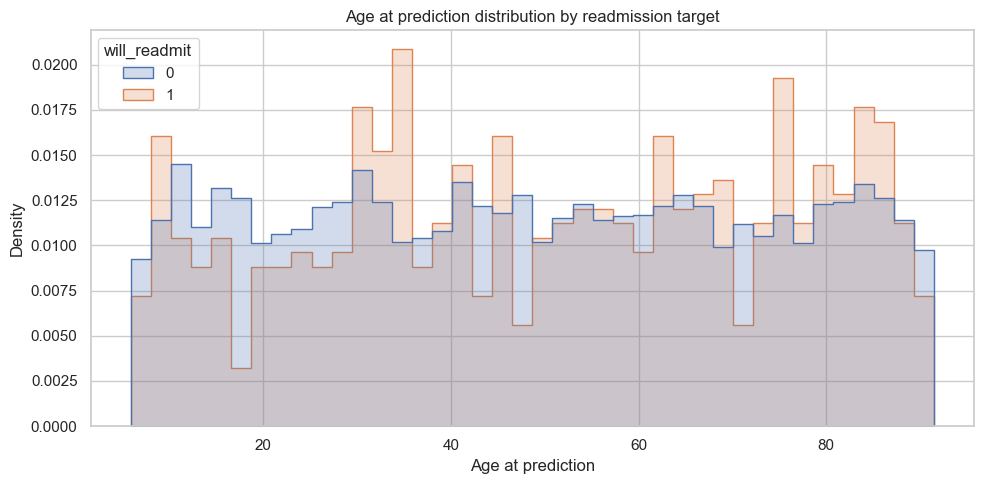

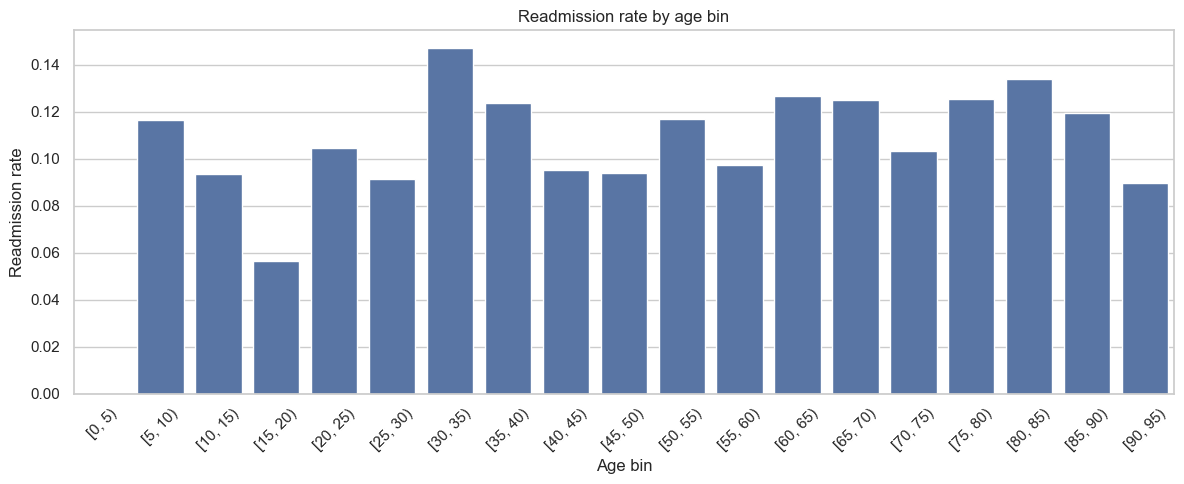

,age_bin,readmission_rate,n
0,"[5, 10)",0.116592,223
1,"[10, 15)",0.093373,332
2,"[15, 20)",0.056478,301
3,"[20, 25)",0.104693,277
4,"[25, 30)",0.091463,328
5,"[30, 35)",0.147309,353
6,"[35, 40)",0.123636,275
7,"[40, 45)",0.095092,326
8,"[45, 50)",0.093851,309
9,"[50, 55)",0.116883,308


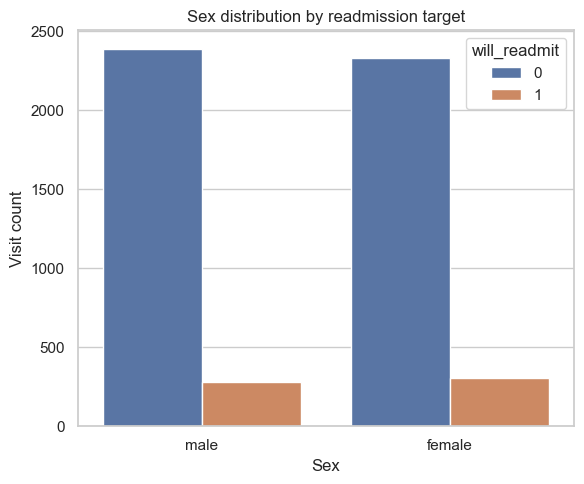

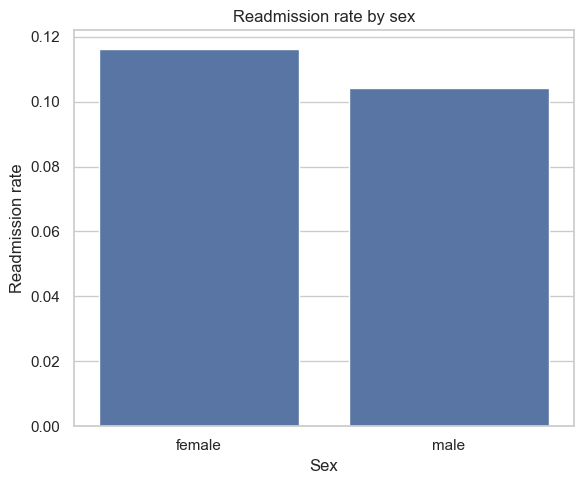

,sex,readmission_rate,n
0,female,0.116129,2635
1,male,0.104057,2662


In [7]:
# ---------------------------------------------------------------------
# EDA: Age and sex by readmission target
# ---------------------------------------------------------------------

eda_demo = primary.copy()
eda_demo["will_readmit"] = eda_demo["will_readmit"].astype(int)

# Age bins by decade
eda_demo["age_bin"] = pd.cut(
    eda_demo["age_at_prediction"],
    bins=list(range(0, 100, 5)),
    right=False,
    include_lowest=True,
)

# ---------------------------------------------------------------------
# Age distribution by target
# ---------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.histplot(
    data=eda_demo,
    x="age_at_prediction",
    hue="will_readmit",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
)
plt.title("Age at prediction distribution by readmission target")
plt.xlabel("Age at prediction")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Readmission rate by age bin
# ---------------------------------------------------------------------

age_rate = (
    eda_demo.groupby("age_bin", observed=True)["will_readmit"]
    .agg(readmission_rate="mean", n="count")
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=age_rate,
    x="age_bin",
    y="readmission_rate",
)
plt.title("Readmission rate by age bin")
plt.xlabel("Age bin")
plt.ylabel("Readmission rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(age_rate)

# ---------------------------------------------------------------------
# Sex distribution by target
# ---------------------------------------------------------------------

plt.figure(figsize=(6, 5))
sns.countplot(
    data=eda_demo,
    x="sex",
    hue="will_readmit",
)
plt.title("Sex distribution by readmission target")
plt.xlabel("Sex")
plt.ylabel("Visit count")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Readmission rate by sex
# ---------------------------------------------------------------------

sex_rate = (
    eda_demo.groupby("sex")["will_readmit"]
    .agg(readmission_rate="mean", n="count")
    .reset_index()
)

plt.figure(figsize=(6, 5))
sns.barplot(
    data=sex_rate,
    x="sex",
    y="readmission_rate",
)
plt.title("Readmission rate by sex")
plt.xlabel("Sex")
plt.ylabel("Readmission rate")
plt.tight_layout()
plt.show()

display(sex_rate)

### Demographic EDA Summary

The cohort appears relatively balanced across both age and sex distributions. Age distributions between readmitted and non-readmitted encounters are broadly overlapping, with no single demographic group fully separating the target outcome.

Some age ranges do demonstrate moderately higher readmission rates, particularly patients aged approximately 30–35 and 75–85, where readmission prevalence rises into the ~13–15% range compared to the overall cohort prevalence of ~11%. However, these increases are gradual rather than extreme and do not appear sufficient to independently explain readmission risk.

Sex distributions are also relatively balanced, with similar visit counts between male and female patients. Readmission prevalence is slightly higher among female patients in this cohort, though the difference is modest.

Overall, demographic variables alone appear to provide limited discriminatory power for predicting readmission, suggesting that longitudinal physiologic patterns and prior healthcare utilization are likely more informative predictors.

## Vitals Cleaning and EDA

In [8]:
# ---------------------------------------------------------------------
# Initial vital sign profiling
# ---------------------------------------------------------------------

print("Vitals shape:", vitals_raw.shape)

print("\nDtypes:")
display(vitals_raw.dtypes)

print("\nMissingness:")
display(
    vitals_raw.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_rate")
)

# Summary statistics
summary = vitals_raw[
    [
        "heart_rate",
        "systolic_bp",
        "diastolic_bp",
        "temperature",
    ]
].describe().T

display(summary)

# Min/max inspection
minmax = pd.DataFrame({
    "min": vitals_raw.min(numeric_only=True),
    "max": vitals_raw.max(numeric_only=True),
})

display(minmax)

Vitals shape: (743097, 7)

Dtypes:


timestamp       datetime64[ns]
patient_id              object
visit_id                object
heart_rate               int64
systolic_bp              int64
diastolic_bp             int64
temperature            float64
dtype: object


Missingness:


,missing_rate
timestamp,0.0
patient_id,0.0
visit_id,0.0
heart_rate,0.0
systolic_bp,0.0
diastolic_bp,0.0
temperature,0.0


,count,mean,std,min,25%,50%,75%,max
heart_rate,743097.0,70.000476,8.719922,54.0,63.0,70.0,77.0,86.0
systolic_bp,743097.0,100.250755,11.733043,79.0,90.0,100.0,110.0,121.0
diastolic_bp,743097.0,90.020281,14.469616,64.0,78.0,90.0,102.0,116.0
temperature,743097.0,37.000239,0.316523,36.2,36.7,37.0,37.3,37.8


,min,max
heart_rate,54.0,86.0
systolic_bp,79.0,121.0
diastolic_bp,64.0,116.0
temperature,36.2,37.8


### Vital sign cleaning and plausibility checks

This block cleans and standardizes the vitals data before modeling. Temperatures greater than 80 are assumed to be recorded in Fahrenheit and are converted to Celsius. Blood pressure rows are checked for likely systolic/diastolic swaps; because systolic BP should generally be higher than diastolic BP, rows where `systolic_bp < diastolic_bp` are flagged and swapped.

The code also creates out-of-bounds flags using broad physiologic plausibility ranges. These are not “normal” clinical ranges; they are intentionally wide thresholds used to flag likely data-entry, parsing, or unit errors.

| Variable | Plausibility range used | Why this range is used |
|---|---:|---|
| `heart_rate` | 25–220 bpm | Allows extreme but possible bradycardia/tachycardia while flagging likely errors |
| `systolic_bp` | 60–250 mmHg | Allows severe hypotension/hypertension while flagging implausible values |
| `diastolic_bp` | 30–150 mmHg | Allows severe low/high diastolic pressure while flagging implausible values |
| `temperature` | 30–45°C | Allows severe hypothermia/hyperthermia while flagging likely unit errors |

Finally, the block creates derived vitals features: mean arterial pressure (`map_bp`), pulse pressure, and shock index.

Reference anchors: MedlinePlus and Cleveland Clinic clinical guidance for normal/abnormal heart rate, blood pressure, fever, hypothermia, and hyperpyrexia ranges.

In [9]:
# ---------------------------------------------------------------------
# Potentially suspicious / implausible values
# ---------------------------------------------------------------------

print("\nPotential Fahrenheit temperatures (>80):")
print((vitals_raw["temperature"] > 80).sum())

print("\nPotential BP swaps (SBP < DBP):")
print(
    (
        vitals_raw["systolic_bp"] <
        vitals_raw["diastolic_bp"]
    ).sum()
)

# Heart rate plausibility checks
print("\nPotentially low heart rates (<25):")
print((vitals_raw["heart_rate"] < 25).sum())

print("\nPotentially high heart rates (>220):")
print((vitals_raw["heart_rate"] > 220).sum())


Potential Fahrenheit temperatures (>80):
0

Potential BP swaps (SBP < DBP):
218363

Potentially low heart rates (<25):
0

Potentially high heart rates (>220):
0


In [10]:
vitals = vitals_raw.copy()

# ---------------------------------------------------------------------
# Blood pressure cleanup
# ---------------------------------------------------------------------

# Flag likely systolic/diastolic swaps
vitals["bp_swapped"] = (
    vitals["systolic_bp"] < vitals["diastolic_bp"]
).astype(int)

# Swap BP values where systolic is lower than diastolic
mask_swap = vitals["bp_swapped"] == 1

vitals.loc[mask_swap, ["systolic_bp", "diastolic_bp"]] = (
    vitals.loc[mask_swap, ["diastolic_bp", "systolic_bp"]].values
)

# ---------------------------------------------------------------------
# Data-quality flags
# ---------------------------------------------------------------------

# No Fahrenheit temperatures or heart-rate outliers were identified
# BP plausibility flags after correcting likely swaps
vitals["systolic_bp_oob"] = (
    (vitals["systolic_bp"] < 60) |
    (vitals["systolic_bp"] > 250)
).astype(int)

vitals["diastolic_bp_oob"] = (
    (vitals["diastolic_bp"] < 30) |
    (vitals["diastolic_bp"] > 150)
).astype(int)

# ---------------------------------------------------------------------
# Derived vital sign features
# ---------------------------------------------------------------------

# Mean arterial pressure
vitals["map_bp"] = (
    vitals["systolic_bp"] + 2 * vitals["diastolic_bp"]
) / 3.0

# Difference between systolic and diastolic BP
vitals["pulse_pressure"] = (
    vitals["systolic_bp"] - vitals["diastolic_bp"]
)

# Heart rate normalized by systolic BP
vitals["shock_index"] = (
    vitals["heart_rate"] / vitals["systolic_bp"].replace(0, np.nan)
)

## EDA on vitals
These plots inspect raw vital sign distributions before visit-level aggregation. They are used primarily for data-quality review and to understand measurement ranges.

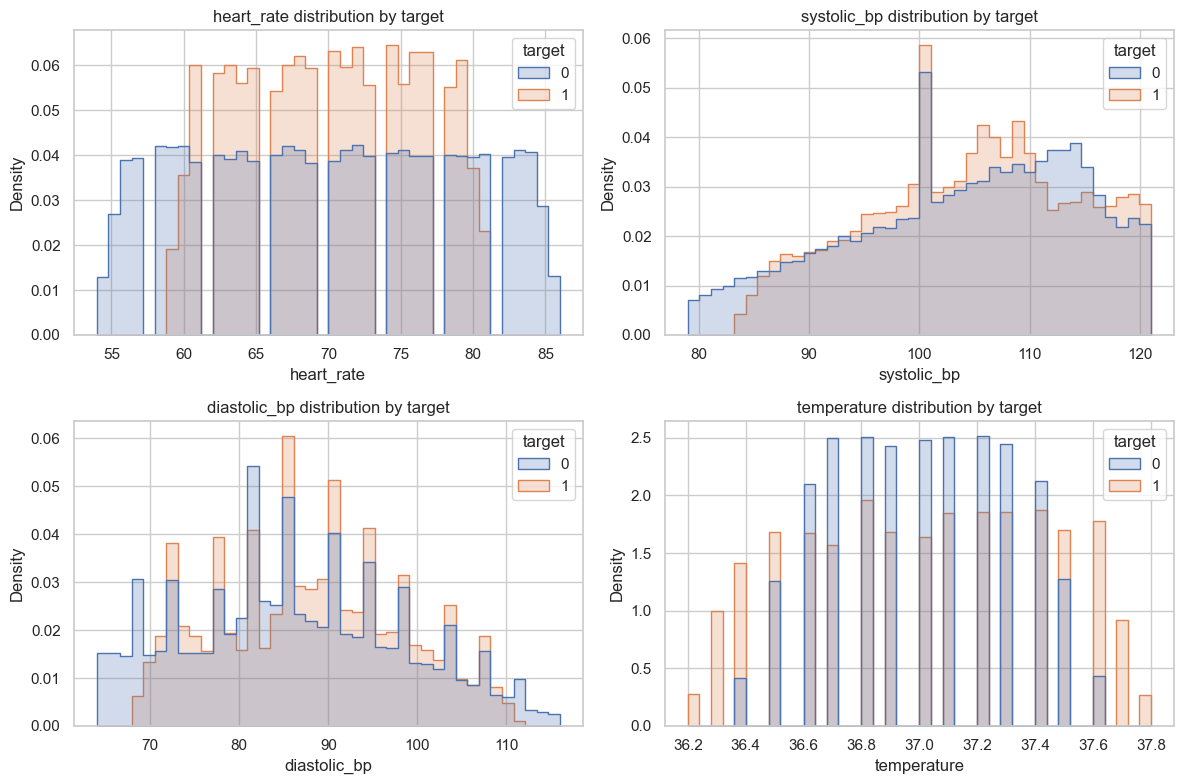

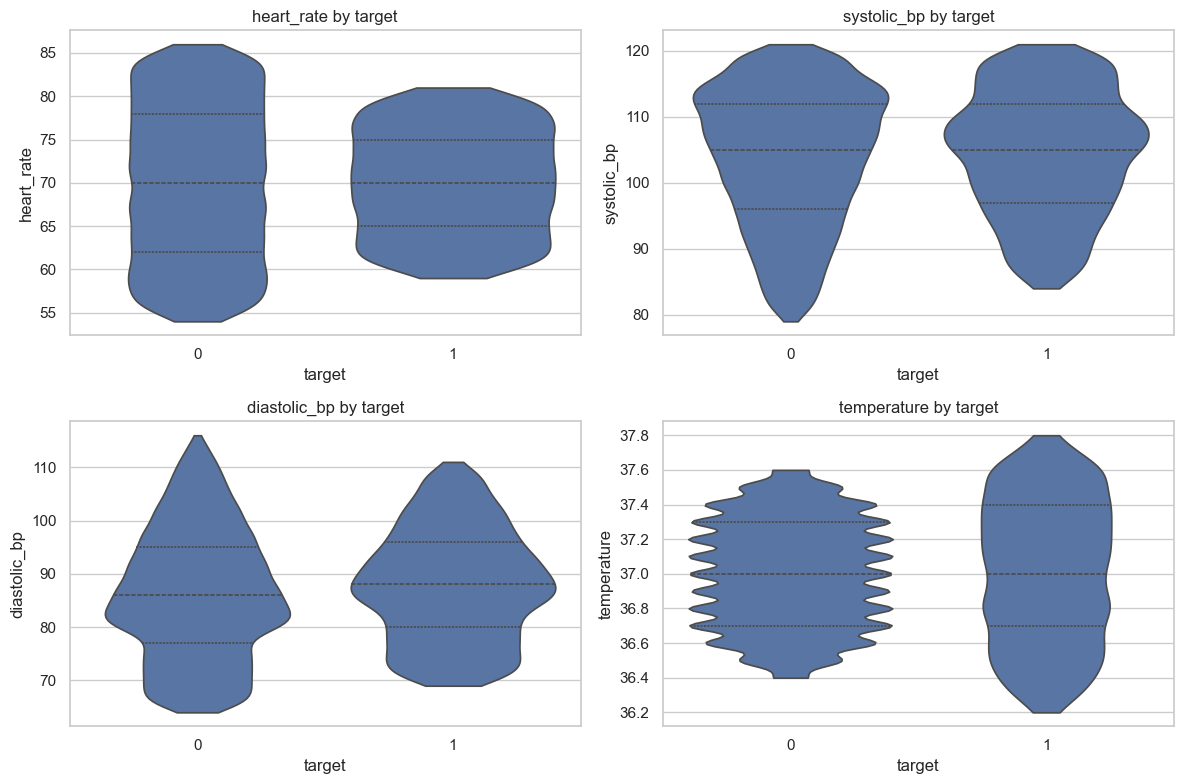

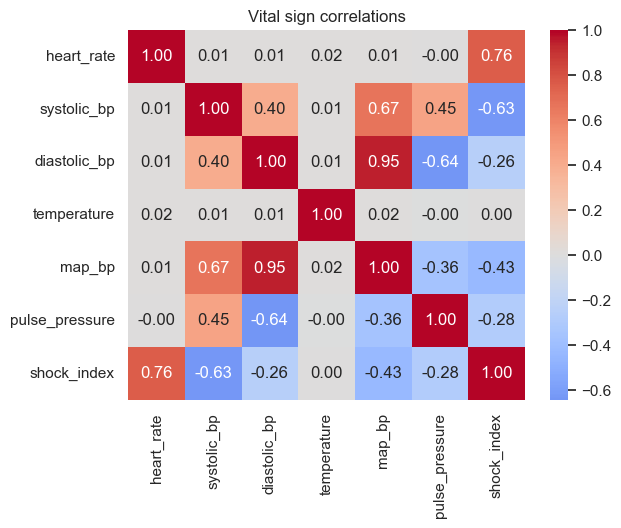

In [11]:
cohort_vitals = vitals.merge(primary[["visit_id","target"]], on="visit_id")
v_sample = cohort_vitals.sample(min(50000,len(cohort_vitals)), random_state=RANDOM_STATE)

measures = ["heart_rate","systolic_bp","diastolic_bp","temperature"]
fig, axs = plt.subplots(2,2, figsize=(12,8))
for ax,feat in zip(axs.flat, measures):
    sns.histplot(data=v_sample, x=feat, hue="target", stat="density", common_norm=False, bins=40, element="step", ax=ax)
    ax.set_title(f"{feat} distribution by target")
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(2,2, figsize=(12,8))
for ax,feat in zip(axs.flat, measures):
    sns.violinplot(x="target", y=feat, data=v_sample, cut=0, inner="quartile", ax=ax)
    ax.set_title(f"{feat} by target")
plt.tight_layout(); plt.show()

corr = v_sample[measures+["map_bp","pulse_pressure","shock_index"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0); plt.title("Vital sign correlations")
plt.show()

In [12]:
desc = v_sample[measures+["map_bp","pulse_pressure","shock_index"]].describe(percentiles=[0.01,0.05,0.25,0.75,0.95,0.99]).T
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
heart_rate,50000.0,70.029680,8.713447,54.000000,55.000000,56.000000,63.000000,70.000000,77.000000,84.000000,85.000000,86.000000
systolic_bp,50000.0,103.827020,10.271113,79.000000,81.000000,85.000000,96.000000,105.000000,112.000000,118.000000,120.000000,121.000000
diastolic_bp,50000.0,86.478360,11.983866,64.000000,65.000000,67.000000,78.000000,86.000000,95.000000,107.000000,112.010000,116.000000
temperature,50000.0,37.002324,0.318612,36.200000,36.400000,36.500000,36.700000,37.000000,37.300000,37.500000,37.600000,37.800000
map_bp,50000.0,92.261247,9.864416,69.000000,72.666667,76.666667,85.000000,91.666667,99.333333,109.333333,113.666667,117.666667
pulse_pressure,50000.0,17.348660,12.296448,0.000000,0.000000,1.000000,7.000000,15.000000,25.000000,41.000000,49.000000,55.000000
shock_index,50000.0,0.681440,0.110833,0.453782,0.482456,0.514286,0.598214,0.674157,0.750000,0.882979,0.975610,1.063291


### Raw Vital Sign EDA Summary

Initial EDA of the raw vital sign measurements demonstrated substantial overlap between readmitted and non-readmitted encounters across heart rate, blood pressure, and temperature distributions. No single raw physiologic measurement appeared to independently separate the target outcome, suggesting that longitudinal trends and temporal variability may be more informative than isolated measurements alone.

Patients who were ultimately readmitted showed mildly higher distributions of:
- Heart rate
- Diastolic blood pressure
- Temperature
- Shock index

These differences were modest but directionally consistent with increased physiologic instability and illness severity.

Correlation analysis identified several expected physiologic relationships:
- Mean arterial pressure (MAP) was highly correlated with diastolic blood pressure
- Shock index showed strong positive correlation with heart rate and negative correlation with systolic blood pressure
- Pulse pressure demonstrated inverse correlation with diastolic blood pressure

These findings are clinically reasonable and support the validity of the derived vital sign features.

Overall, the raw vital sign EDA suggests that:
- Physiologic signal related to readmission risk is likely subtle
- Derived features summarizing variability, trajectory, and instability may provide more predictive value than raw measurements alone
- Some engineered features may introduce redundancy due to strong physiologic correlation structures

## First-score vitals window
Restrict vitals to the prediction window before first eligible 6AM

In [13]:
# Restrict vitals to the prediction window before first eligible 6AM
vitals_window = vitals.merge(
    primary[
        [
            "visit_id",
            "patient_id",
            "ed_arrival",
            "admission",
            "score_time",
        ]
    ],
    on=["visit_id", "patient_id"],
    how="inner",
)

# Keep only vitals observed before prediction time
vitals_window = vitals_window[
    (vitals_window["timestamp"] >= vitals_window["ed_arrival"]) &
    (vitals_window["timestamp"] <= vitals_window["score_time"])
].copy()

# Hours since ED arrival
vitals_window["hrs_from_ed"] = (
    vitals_window["timestamp"] - vitals_window["ed_arrival"]
).dt.total_seconds() / 3600

# Hours since admission
vitals_window["hrs_from_adm"] = (
    vitals_window["timestamp"] - vitals_window["admission"]
).dt.total_seconds() / 3600

# Coverage summary
coverage = {
    "visits": len(primary),
    "visits_with_vitals": vitals_window["visit_id"].nunique(),
    "vital_rows_window": len(vitals_window),
}

print(coverage)

{'visits': 5297, 'visits_with_vitals': 5297, 'vital_rows_window': 129647}


## Feature Engineering

In [14]:
# ---------------------------------------------------------------------
# Build deployment-aligned visit-level features
#
# Assignment alignment:
#   - Model runs daily at 6AM on current admitted patients.
#   - If a patient arrives/admitted after 6AM, first prediction is next morning.
#   - Features should only use information available at prediction time.
#
# Creates:
#   1) First scheduled prediction timestamp per visit
#   2) Prior utilization/readmission-history features available by prediction time
#   3) Vitals trajectory/summary features using vitals up to prediction time only
#
# Removed:
#   - Threshold count/rate/prop features
# ---------------------------------------------------------------------

VITALS = [
    "heart_rate",
    "systolic_bp",
    "diastolic_bp",
    "temperature",
    "map_bp",
    "pulse_pressure",
    "shock_index",
]

# ---------------------------------------------------------------------
# Helper: first scheduled 6AM prediction time
# ---------------------------------------------------------------------

def first_6am_prediction_time(admission_time):
    """
    Returns the first 6AM prediction time after admission.

    If admitted at or before 6AM, prediction can run that same day at 6AM.
    If admitted after 6AM, first prediction is the next day at 6AM.
    """
    admission_time = pd.to_datetime(admission_time)

    six_am_same_day = admission_time.normalize() + pd.Timedelta(hours=6)

    if admission_time <= six_am_same_day:
        return six_am_same_day
    else:
        return six_am_same_day + pd.Timedelta(days=1)


# ---------------------------------------------------------------------
# Prepare primary cohort with deployment-aligned prediction time
# ---------------------------------------------------------------------

primary_model = primary.copy()

for col in ["ed_arrival", "admission", "discharge"]:
    primary_model[col] = pd.to_datetime(primary_model[col])

primary_model["prediction_time"] = primary_model["admission"].apply(first_6am_prediction_time)

# Keep only visits where the patient would actually be current/in scope
# at their first scheduled 6AM prediction time.
primary_model["eligible_for_first_6am_score"] = (
    (primary_model["admission"] <= primary_model["prediction_time"]) &
    (primary_model["discharge"] >= primary_model["prediction_time"])
).astype(int)

primary_model = primary_model[
    primary_model["eligible_for_first_6am_score"] == 1
].copy()

# Time available since admission at prediction time
primary_model["hrs_admitted_at_prediction"] = (
    primary_model["prediction_time"] - primary_model["admission"]
).dt.total_seconds() / 3600

primary_model["hrs_from_ed_to_prediction"] = (
    primary_model["prediction_time"] - primary_model["ed_arrival"]
).dt.total_seconds() / 3600


# ---------------------------------------------------------------------
# Prior utilization / prior readmission features
# ---------------------------------------------------------------------
# Uses only encounters that occurred before the current prediction time.

history = visits[
    ["patient_id", "visit_id", "admission", "discharge"]
].copy()

history["admission"] = pd.to_datetime(history["admission"])
history["discharge"] = pd.to_datetime(history["discharge"])

history = history.sort_values(
    ["patient_id", "admission", "discharge"]
).reset_index(drop=True)


def build_prior_history_features(current_visits, all_visits, windows=(30, 180)):
    """
    For each current visit, create prior utilization features using only prior
    encounters with discharge <= current prediction_time.
    """
    rows = []

    all_visits = all_visits.sort_values(
        ["patient_id", "admission", "discharge"]
    ).copy()

    for _, row in current_visits.iterrows():
        patient_id = row["patient_id"]
        visit_id = row["visit_id"]
        admission = row["admission"]
        prediction_time = row["prediction_time"]

        prior = all_visits[
            (all_visits["patient_id"] == patient_id) &
            (all_visits["visit_id"] != visit_id) &
            (all_visits["discharge"] <= prediction_time)
        ].copy()

        prior = prior.sort_values("discharge")

        out = {
            "visit_id": visit_id,
            "prior_visit_count": len(prior),
            "has_prior_visit": int(len(prior) > 0),
            "days_since_prev_discharge": np.nan,
            "prior_readmit_30d": 0,
            "history_prior_readmit_30d": 0,
            "prior_readmit_30d_count_before": 0,
        }

        if len(prior) > 0:
            prev_discharge = prior["discharge"].max()

            out["days_since_prev_discharge"] = (
                admission - prev_discharge
            ).total_seconds() / (3600 * 24)

            out["prior_readmit_30d"] = int(
                (out["days_since_prev_discharge"] >= 0) &
                (out["days_since_prev_discharge"] <= 30)
            )

            # Count historical 30-day readmission patterns before this visit.
            prior_sorted = prior.sort_values("admission").copy()
            prior_sorted["prev_discharge"] = prior_sorted["discharge"].shift(1)

            prior_sorted["days_since_prior_discharge"] = (
                prior_sorted["admission"] - prior_sorted["prev_discharge"]
            ).dt.total_seconds() / (3600 * 24)

            prior_sorted["was_30d_readmission"] = (
                (prior_sorted["days_since_prior_discharge"] >= 0) &
                (prior_sorted["days_since_prior_discharge"] <= 30)
            ).astype(int)

            out["prior_readmit_30d_count_before"] = int(
                prior_sorted["was_30d_readmission"].sum()
            )

            out["history_prior_readmit_30d"] = int(
                out["prior_readmit_30d_count_before"] > 0
            )

        for window in windows:
            window_start = admission - pd.Timedelta(days=window)

            out[f"prior_{window}d_visit_count"] = int(
                (
                    (prior["admission"] < admission) &
                    (prior["admission"] >= window_start)
                ).sum()
            )

        rows.append(out)

    return pd.DataFrame(rows)


history_features = build_prior_history_features(
    current_visits=primary_model,
    all_visits=history,
    windows=(30, 180),
)


# ---------------------------------------------------------------------
# Prepare vitals using only values available by prediction time
# ---------------------------------------------------------------------

vitals_model = vitals_window.copy()

vitals_model["timestamp"] = pd.to_datetime(vitals_model["timestamp"])

# Remove helper columns from prior runs so the cell is rerunnable
vitals_model = vitals_model.drop(
    columns=[
        "prediction_time",
        "admission",
        "hrs_from_adm",
        "hrs_to_prediction",
        "half_cut",
        "half_window",
    ],
    errors="ignore",
)

# Attach each visit's admission and prediction timestamp
vitals_model = vitals_model.merge(
    primary_model[["visit_id", "admission", "prediction_time"]],
    on="visit_id",
    how="inner",
)

# Keep only vitals available at inference time
vitals_model = vitals_model[
    vitals_model["timestamp"] <= vitals_model["prediction_time"]
].copy()

# Time features relative to admission and prediction time
vitals_model["hrs_from_adm"] = (
    vitals_model["timestamp"] - vitals_model["admission"]
).dt.total_seconds() / 3600

vitals_model["hrs_to_prediction"] = (
    vitals_model["prediction_time"] - vitals_model["timestamp"]
).dt.total_seconds() / 3600

# Drop vitals before admission if you want strictly inpatient vitals.
# If you want to include ED vitals, remove this filter.
vitals_model = vitals_model[
    vitals_model["hrs_from_adm"] >= 0
].copy()

vitals_model = (
    vitals_model
    .sort_values(["visit_id", "timestamp"])
    .reset_index(drop=True)
)

grouped = vitals_model.groupby("visit_id", sort=False)


# ---------------------------------------------------------------------
# Visit-level vitals metadata and data-quality rates
# ---------------------------------------------------------------------

meta = grouped.agg(
    vital_count=("timestamp", "size"),
    first_vital_time=("timestamp", "min"),
    last_vital_time=("timestamp", "max"),
    first_hr=("hrs_from_adm", "min"),
    last_hr=("hrs_from_adm", "max"),
    bp_swapped_rate=("bp_swapped", "mean"),
    sbp_oob_rate=("systolic_bp_oob", "mean"),
    dbp_oob_rate=("diastolic_bp_oob", "mean")
)

meta["hours_observed"] = (
    (meta["last_vital_time"] - meta["first_vital_time"]).dt.total_seconds() / 3600
).clip(lower=1e-6)

meta["obs_density"] = meta["vital_count"] / meta["hours_observed"]

# How close the latest vital was to prediction time
last_available_vital = grouped["hrs_to_prediction"].min()
meta["hrs_since_last_vital_at_prediction"] = last_available_vital

# Gaps between vital measurements
gaps = grouped["timestamp"].diff().dt.total_seconds() / 3600

gap_stats = gaps.groupby(vitals_model["visit_id"]).agg(
    gap_mean="mean",
    gap_median="median",
    gap_std="std",
    gap_max="max",
)

meta = meta.join(gap_stats)

frames = [meta]


# ---------------------------------------------------------------------
# Summary statistics for each vital sign
# ---------------------------------------------------------------------

for feat in VITALS:
    agg = grouped[feat].agg(
        ["first", "last", "mean", "median", "min", "max", "std", "skew"]
    )

    agg.columns = [f"{feat}_{col}" for col in agg.columns]

    quantiles = grouped[feat].quantile([0.10, 0.25, 0.75, 0.90]).unstack()

    quantiles = quantiles.rename(
        columns={
            0.10: f"{feat}_q10",
            0.25: f"{feat}_q25",
            0.75: f"{feat}_q75",
            0.90: f"{feat}_q90",
        }
    )

    agg = agg.join(quantiles)

    agg[f"{feat}_range"] = agg[f"{feat}_max"] - agg[f"{feat}_min"]
    agg[f"{feat}_iqr"] = agg[f"{feat}_q75"] - agg[f"{feat}_q25"]
    agg[f"{feat}_cv"] = agg[f"{feat}_std"] / agg[f"{feat}_mean"].replace(0, np.nan)
    agg[f"{feat}_delta"] = agg[f"{feat}_last"] - agg[f"{feat}_first"]

    frames.append(agg)


# ---------------------------------------------------------------------
# Slope per hour for each vital sign
# ---------------------------------------------------------------------

slope_rows = []

for visit_id, dfv in grouped:
    row = {"visit_id": visit_id}

    for feat in VITALS:
        tmp = dfv[["hrs_from_adm", feat]].dropna()

        x = tmp["hrs_from_adm"].values
        y = tmp[feat].values

        if len(tmp) < 2 or np.std(x) == 0:
            slope = 0.0
        else:
            slope = float(np.polyfit(x, y, 1)[0])

        row[f"{feat}_slope_per_hr"] = slope

    slope_rows.append(row)

slope_df = pd.DataFrame(slope_rows).set_index("visit_id")
frames.append(slope_df)


# ---------------------------------------------------------------------
# First-half vs second-half means within available pre-prediction window
# ---------------------------------------------------------------------

half_cut = meta["first_hr"] + ((meta["last_hr"] - meta["first_hr"]) / 2.0)

vitals_model["half_cut"] = vitals_model["visit_id"].map(half_cut)

vitals_model["half_window"] = np.where(
    vitals_model["hrs_from_adm"] <= vitals_model["half_cut"],
    "first",
    "second",
)

for feat in VITALS:
    means = vitals_model.pivot_table(
        index="visit_id",
        columns="half_window",
        values=feat,
        aggfunc="mean",
    )

    means = means.reindex(columns=["first", "second"])

    means.columns = [
        f"{feat}_first_half",
        f"{feat}_second_half",
    ]

    means[f"{feat}_diff"] = (
        means[f"{feat}_second_half"] - means[f"{feat}_first_half"]
    )

    frames.append(means)


# ---------------------------------------------------------------------
# Combine vitals features
# ---------------------------------------------------------------------

feature_df = pd.concat(frames, axis=1).reset_index()

if "index" in feature_df.columns:
    feature_df = feature_df.rename(columns={"index": "visit_id"})


# ---------------------------------------------------------------------
# Merge prior-history features + vitals features back to modeling cohort
# ---------------------------------------------------------------------

cohort = (
    primary_model
    .merge(history_features, on="visit_id", how="left")
    .merge(feature_df, on="visit_id", how="left")
)


# ---------------------------------------------------------------------
# Cleanup / sanity checks
# ---------------------------------------------------------------------

# Flag whether the patient had any vitals available before prediction time
cohort["has_pre_prediction_vitals"] = cohort["vital_count"].notna().astype(int)

# For metadata/count-like columns, missing means no vitals were available
vital_count_like_cols = [
    "vital_count",
    "bp_swapped_rate",
    "temp_F_rate",
    "hr_oob_rate",
    "sbp_oob_rate",
    "dbp_oob_rate",
    "temp_oob_rate",
    "hours_observed",
    "obs_density",
]

for col in vital_count_like_cols:
    if col in cohort.columns:
        cohort[col] = cohort[col].fillna(0)

# Note to self: do NOT fill days_since_prev_discharge with 0; missing means no prior discharge.
print("Original primary rows:", len(primary))
print("Eligible for first 6AM scoring:", len(primary_model))
print("Rows with available pre-prediction vitals:", len(feature_df))
print("Final modeling cohort rows:", len(cohort))

if "target" in cohort.columns:
    print("Readmit rate:", cohort["target"].mean())
elif "will_readmit" in cohort.columns:
    print("Readmit rate:", cohort["will_readmit"].mean())

display(
    cohort[
        [
            "visit_id",
            "patient_id",
            "admission",
            "discharge",
            "prediction_time",
            "hrs_admitted_at_prediction",
            "prior_visit_count",
            "prior_readmit_30d",
            "prior_30d_visit_count",
            "prior_180d_visit_count",
            "vital_count",
            "first_vital_time",
            "last_vital_time",
            "hrs_since_last_vital_at_prediction",
        ]
    ].head()
)

Original primary rows: 5297
Eligible for first 6AM scoring: 5297
Rows with available pre-prediction vitals: 5166
Final modeling cohort rows: 5297
Readmit rate: 0.11006229941476307


,visit_id,patient_id,admission,discharge,prediction_time,hrs_admitted_at_prediction,prior_visit_count,prior_readmit_30d,prior_30d_visit_count,prior_180d_visit_count,vital_count,first_vital_time,last_vital_time,hrs_since_last_vital_at_prediction
0,506309de-b649-43f3-b57f-0f17f49f2998,00136717-0dff-4d43-ae3d-3e0ec1303bc3,2012-08-08 11:16:00,2012-08-13 11:16:00,2012-08-09 06:00:00,18.733333,0,0,0,0,19.0,2012-08-08 11:24:00,2012-08-09 05:48:00,0.200000
1,f92efacf-7d43-457b-a9ad-8c9ccbaa7708,001afe4c-8dd4-4e27-b22a-589568ccee5d,2012-12-09 04:54:00,2012-12-15 04:54:00,2012-12-09 06:00:00,1.100000,0,0,0,0,2.0,2012-12-09 05:28:00,2012-12-09 05:56:00,0.066667
2,3234c40a-d76c-48ee-8f51-4e8eaf638978,0026005d-1bbe-44c5-ba80-04d4ea3e63bc,2012-08-12 21:39:00,2012-08-19 21:39:00,2012-08-13 06:00:00,8.350000,0,0,0,0,9.0,2012-08-12 22:18:00,2012-08-13 05:47:00,0.216667
3,8722ad61-c788-4695-937f-ec6224c9043a,0036e282-8248-4b26-b27d-b92de26eb295,2012-05-07 05:01:00,2012-05-09 05:01:00,2012-05-07 06:00:00,0.983333,0,0,0,0,1.0,2012-05-07 05:50:00,2012-05-07 05:50:00,0.166667
4,f4e80f9a-5183-4dde-9a8d-a5b7d8e83cf3,00461a8f-5b9a-40eb-930e-20008cba2e01,2012-01-10 04:01:00,2012-01-11 04:01:00,2012-01-10 06:00:00,1.983333,0,0,0,0,2.0,2012-01-10 04:43:00,2012-01-10 05:15:00,0.750000


## Visit level EDA

Cohort shape: (5297, 209)

Target distribution:


,count,prop
will_readmit,,
No readmission,4714,0.889938
Readmission,583,0.110062


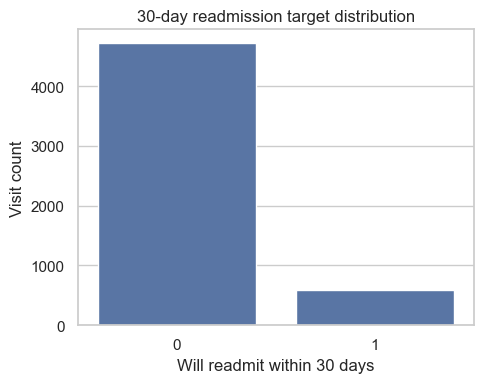

Top missingness differences by target:


will_readmit,no_readmit_missing_rate,readmit_missing_rate,abs_diff
heart_rate_skew,0.109461,0.114923,0.005462
pulse_pressure_skew,0.109461,0.114923,0.005462
shock_index_skew,0.109461,0.114923,0.005462
diastolic_bp_skew,0.109461,0.114923,0.005462
temperature_skew,0.109461,0.114923,0.005462
map_bp_skew,0.109461,0.114923,0.005462
systolic_bp_skew,0.109461,0.114923,0.005462
gap_std,0.109461,0.114923,0.005462
heart_rate_range,0.024820,0.024014,0.000806
systolic_bp_range,0.024820,0.024014,0.000806


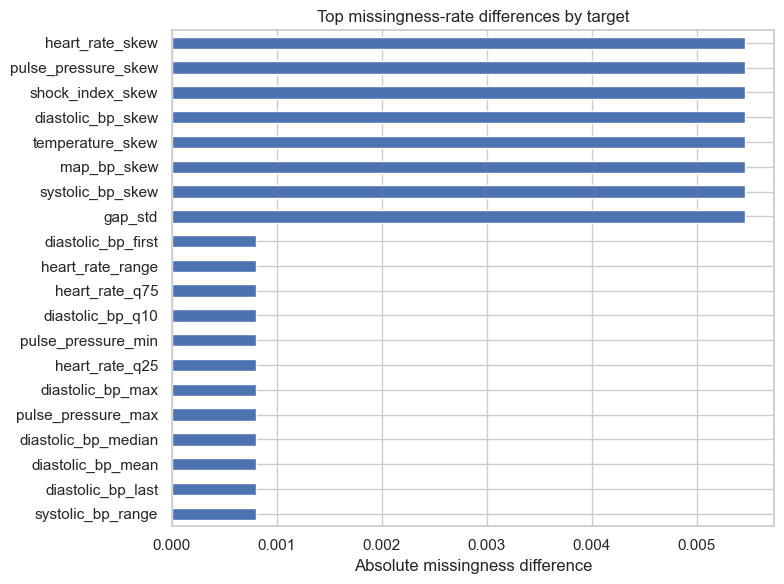

Visit-level numeric summaries by target:


,feature,target,count,mean,std,median,q25,q75,min,max
0,age_at_prediction,0,4714,48.574051,24.594554,48.179265,27.528341,69.808286,5.917800,91.456472
1,age_at_prediction,1,583,50.784093,24.340555,51.612530,31.274405,73.221017,6.246342,91.078649
2,hrs_admitted_at_prediction,0,4714,11.974572,6.982561,12.008333,5.900000,18.016667,0.000000,23.983333
3,hrs_admitted_at_prediction,1,583,12.299628,7.134592,12.533333,5.983333,18.700000,0.016667,23.983333
4,hrs_from_ed_to_prediction,0,4714,24.378688,9.705751,24.325000,17.445833,31.416667,1.183333,47.916667
5,hrs_from_ed_to_prediction,1,583,25.152115,9.787936,25.116667,18.550000,32.275000,2.583333,46.883333
6,prior_visit_count,0,4714,0.119007,0.363353,0.000000,0.000000,0.000000,0.000000,3.000000
7,prior_visit_count,1,583,0.113208,0.338097,0.000000,0.000000,0.000000,0.000000,2.000000
8,prior_30d_visit_count,0,4714,0.085702,0.285952,0.000000,0.000000,0.000000,0.000000,2.000000
9,prior_30d_visit_count,1,583,0.094340,0.298367,0.000000,0.000000,0.000000,0.000000,2.000000


Readmission rate by sex:


will_readmit,no_readmit_rate,readmit_rate
sex,,
female,0.883871,0.116129
male,0.895943,0.104057


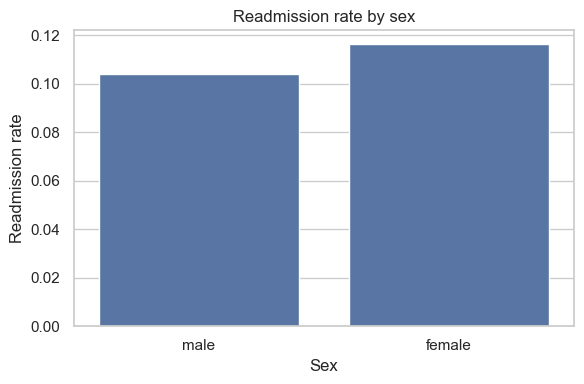

In [15]:
# ---------------------------------------------------------------------
# Visit-level EDA for readmission modeling cohort
# ---------------------------------------------------------------------

eda = cohort.copy()

# Use will_readmit as the label
label_col = "will_readmit"
eda[label_col] = eda[label_col].astype(int)

print("Cohort shape:", eda.shape)
print("\nTarget distribution:")
display(
    eda[label_col]
    .value_counts()
    .rename(index={0: "No readmission", 1: "Readmission"})
    .to_frame("count")
    .assign(prop=lambda x: x["count"] / x["count"].sum())
)

# ---------------------------------------------------------------------
# 1. Target balance
# ---------------------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.countplot(data=eda, x=label_col)
plt.title("30-day readmission target distribution")
plt.xlabel("Will readmit within 30 days")
plt.ylabel("Visit count")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2. Missingness by target
# ---------------------------------------------------------------------

missing_summary = (
    eda
    .isna()
    .groupby(eda[label_col])
    .mean()
    .T
    .rename(columns={0: "no_readmit_missing_rate", 1: "readmit_missing_rate"})
)

missing_summary["abs_diff"] = (
    missing_summary["readmit_missing_rate"] -
    missing_summary["no_readmit_missing_rate"]
).abs()

missing_summary = missing_summary.sort_values("abs_diff", ascending=False)

print("Top missingness differences by target:")
display(missing_summary.head(25))

plt.figure(figsize=(8, 6))
missing_summary.head(20)["abs_diff"].sort_values().plot(kind="barh")
plt.title("Top missingness-rate differences by target")
plt.xlabel("Absolute missingness difference")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3. Basic demographic / visit-level summaries
# ---------------------------------------------------------------------

summary_cols = [
    "age_at_prediction",
    "hrs_admitted_at_prediction",
    "hrs_from_ed_to_prediction",
    "prior_visit_count",
    "prior_30d_visit_count",
    "prior_180d_visit_count",
    "days_since_prev_discharge",
    "vital_count",
    "hours_observed",
    "obs_density",
    "hrs_since_last_vital_at_prediction",
]

summary_cols = [col for col in summary_cols if col in eda.columns]

def summarize_by_target(df, cols, label_col):
    rows = []

    for col in cols:
        tmp = df[[col, label_col]].copy()

        for target_value, dfg in tmp.groupby(label_col):
            rows.append({
                "feature": col,
                "target": target_value,
                "count": dfg[col].notna().sum(),
                "mean": dfg[col].mean(),
                "std": dfg[col].std(),
                "median": dfg[col].median(),
                "q25": dfg[col].quantile(0.25),
                "q75": dfg[col].quantile(0.75),
                "min": dfg[col].min(),
                "max": dfg[col].max(),
            })

    return pd.DataFrame(rows)

visit_summary = summarize_by_target(eda, summary_cols, label_col)

print("Visit-level numeric summaries by target:")
display(visit_summary)

# ---------------------------------------------------------------------
# 4. Sex distribution by target
# ---------------------------------------------------------------------

if "sex" in eda.columns:
    sex_target = pd.crosstab(
        eda["sex"],
        eda[label_col],
        normalize="index"
    ).rename(columns={0: "no_readmit_rate", 1: "readmit_rate"})

    print("Readmission rate by sex:")
    display(sex_target)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=eda, x="sex", y=label_col, errorbar=None)
    plt.title("Readmission rate by sex")
    plt.xlabel("Sex")
    plt.ylabel("Readmission rate")
    plt.tight_layout()
    plt.show()


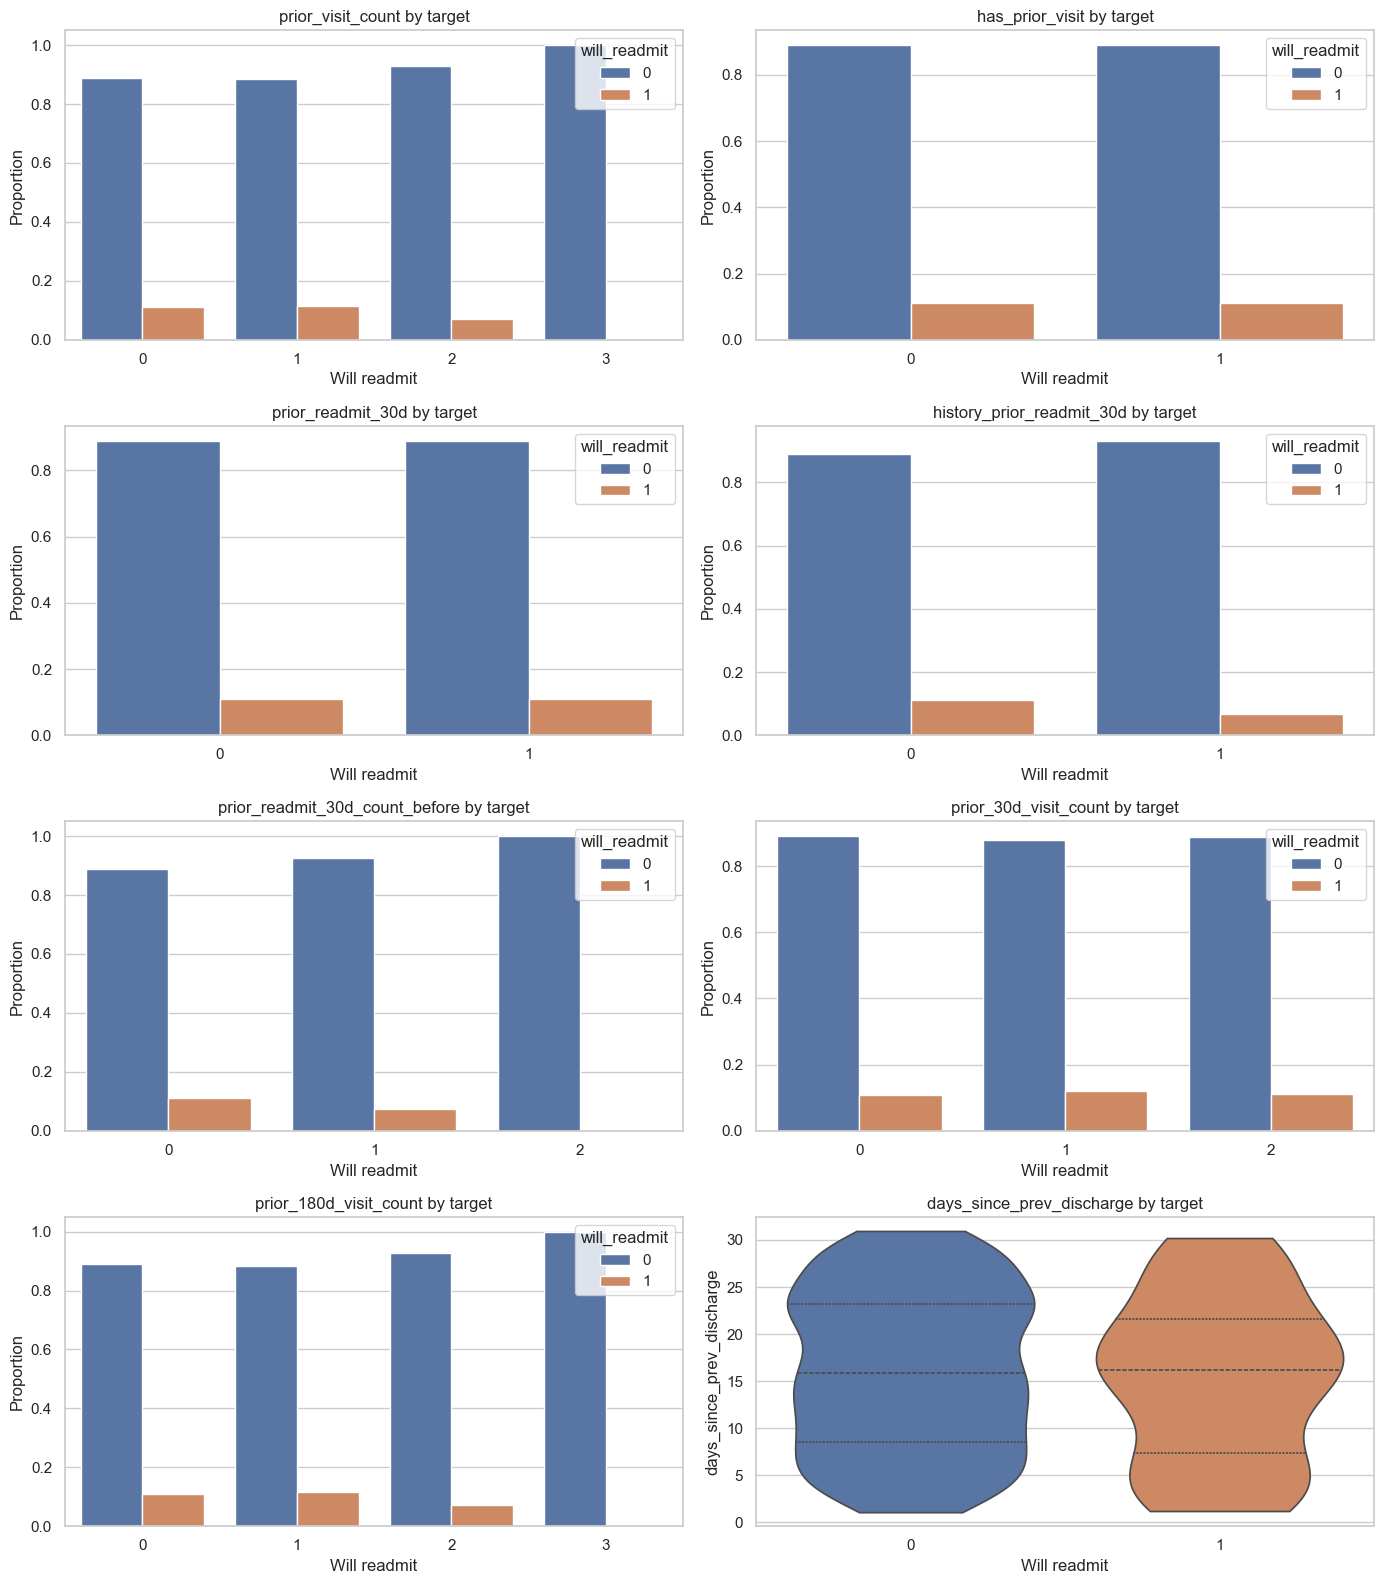

In [16]:
# ---------------------------------------------------------------------
# 5. Prior utilization features by target
# ---------------------------------------------------------------------

prior_features = [
    "prior_visit_count",
    "has_prior_visit",
    "prior_readmit_30d",
    "history_prior_readmit_30d",
    "prior_readmit_30d_count_before",
    "prior_30d_visit_count",
    "prior_180d_visit_count",
    "days_since_prev_discharge",
]

prior_features = [
    col for col in prior_features
    if col in eda.columns
]

n_cols = 2
n_rows = int(np.ceil(len(prior_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows),
)

axes = axes.flatten()

for ax, feat in zip(axes, prior_features):

    # Binary / low-cardinality features
    if eda[feat].nunique(dropna=True) <= 5:

        plot_df = (
            eda.groupby(feat)[label_col]
            .value_counts(normalize=True)
            .rename("proportion")
            .reset_index()
        )

        sns.barplot(
            data=plot_df,
            x=feat,
            y="proportion",
            hue=label_col,
            ax=ax,
        )

        ax.set_ylabel("Proportion")

    # Continuous features
    else:
        sns.violinplot(
            data=eda,
            x=label_col,
            y=feat,
            hue=label_col,
            cut=0,
            inner="quartile",
            legend=False,
            ax=ax,
        )

        ax.set_ylabel(feat)

    ax.set_title(f"{feat} by target")
    ax.set_xlabel("Will readmit")

# Remove empty panels
for ax in axes[len(prior_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

### Prior Utilization Feature EDA Summary

Prior healthcare utilization features demonstrated modest but clinically intuitive relationships with 30-day readmission risk.

Patients with a history of prior encounters or prior readmissions generally showed slightly higher proportions of future readmission compared to patients without prior utilization history. In particular:
- Patients with prior 30-day readmissions demonstrated elevated future readmission prevalence
- Higher prior visit counts and prior short-term utilization were directionally associated with increased readmission risk
- Patients without prior utilization history tended to have lower readmission prevalence overall

The distribution of days since previous discharge also differed modestly between groups, with readmitted patients appearing to cluster somewhat closer to recent prior encounters.

While the effect sizes were not extreme, these findings suggest that prior healthcare utilization patterns contain meaningful predictive signal and may help capture chronic illness burden, healthcare complexity, or recurrent utilization behavior.

Overall, these features appear clinically plausible and likely provide complementary information beyond demographics and raw physiologic measurements alone.

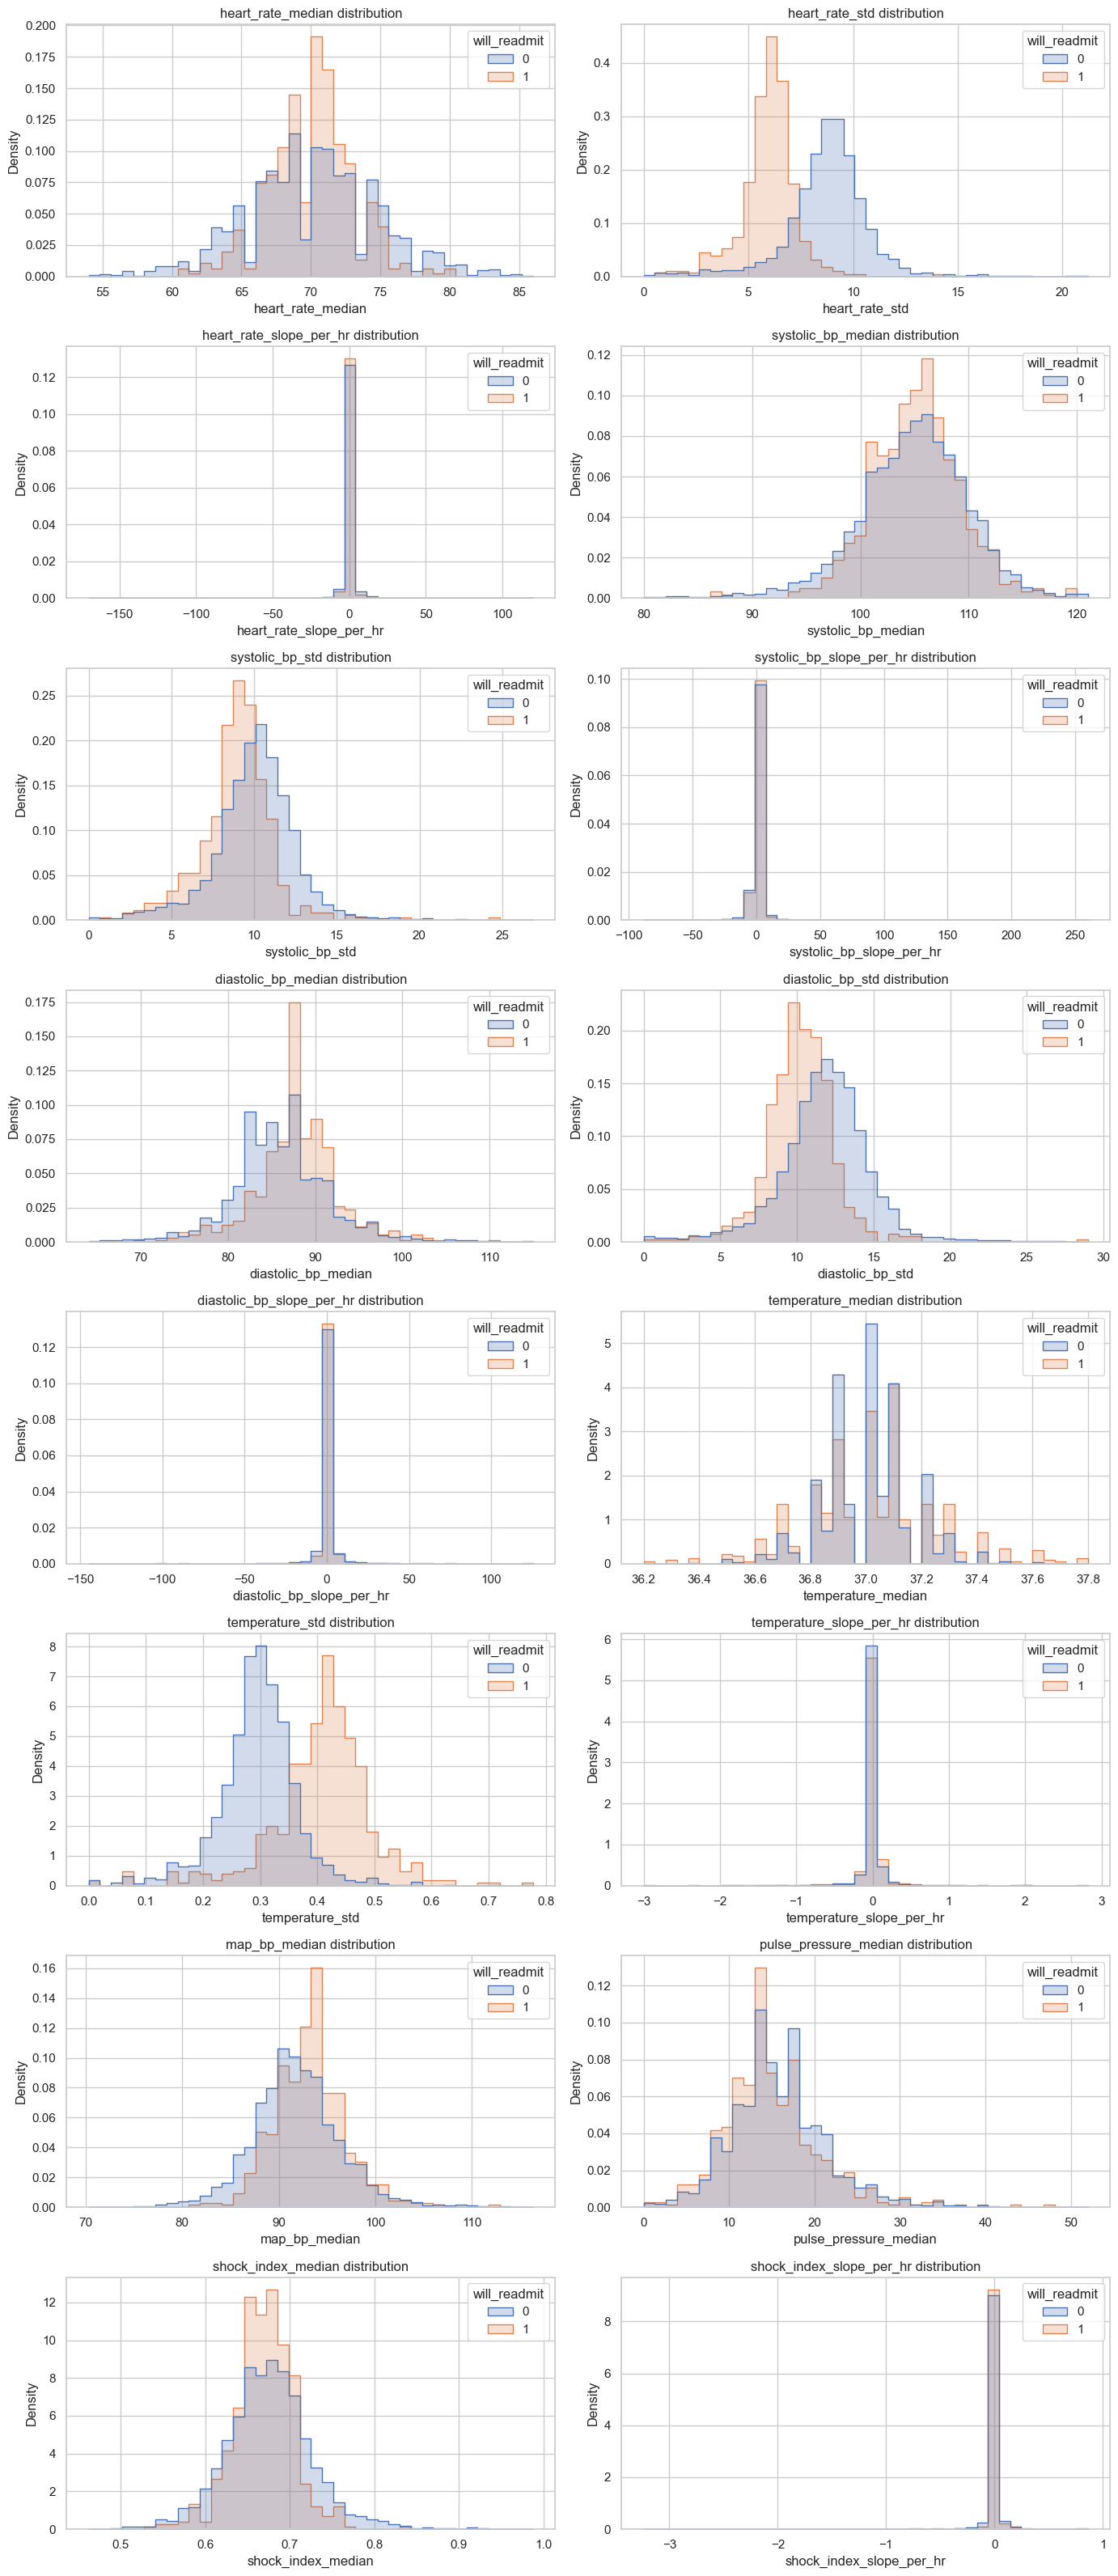

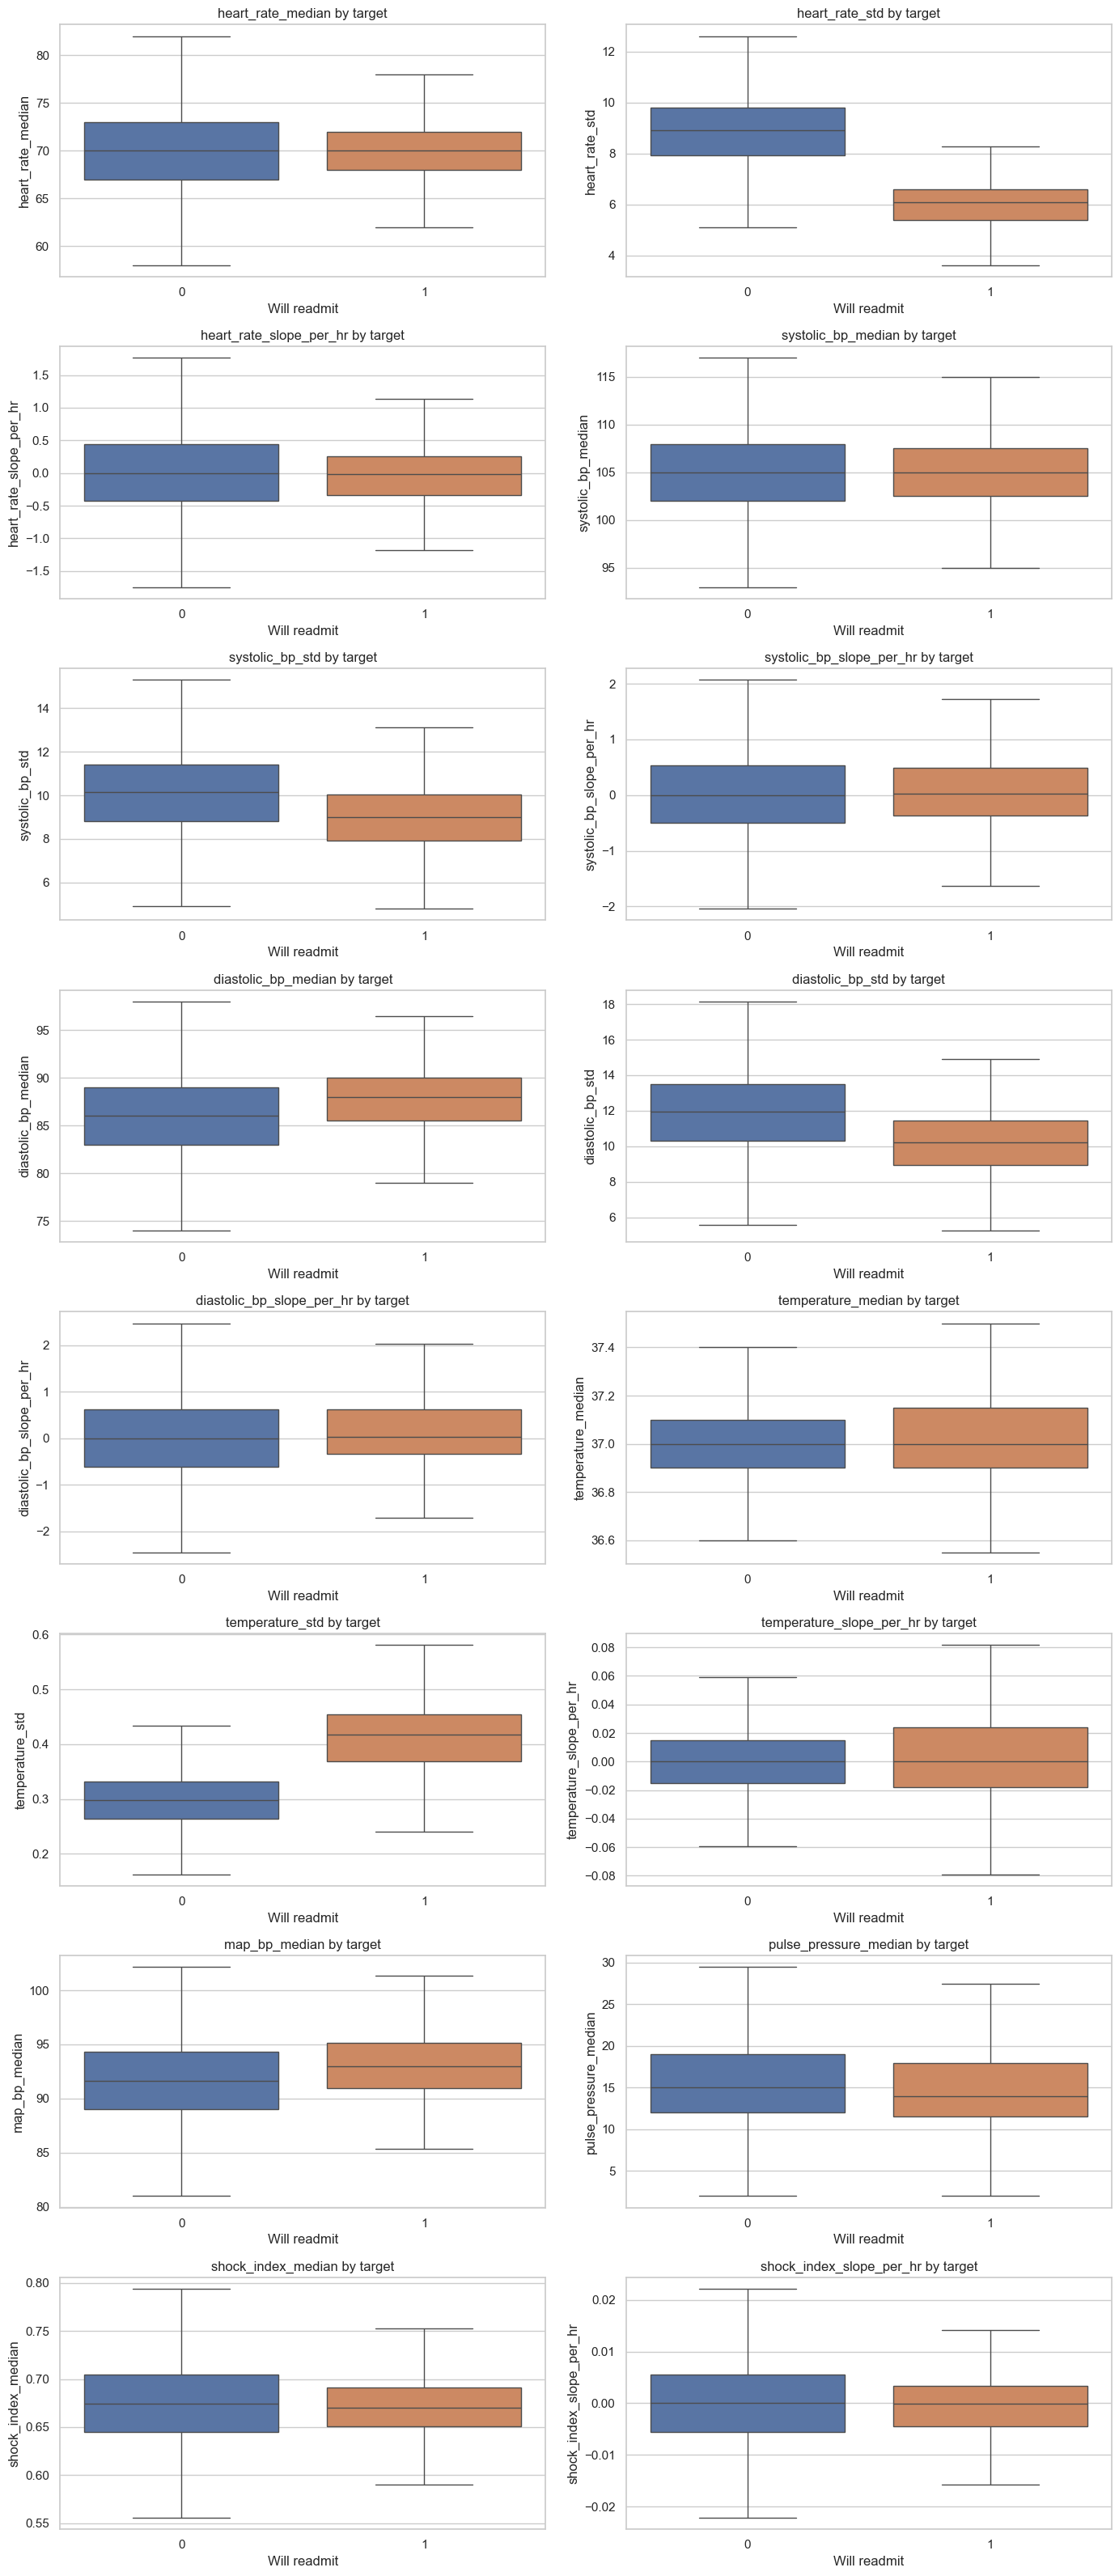

In [17]:
# ---------------------------------------------------------------------
# 6. Vitals summary features by target
# ---------------------------------------------------------------------

vital_summary_features = [
    "heart_rate_median",
    "heart_rate_std",
    "heart_rate_slope_per_hr",
    "systolic_bp_median",
    "systolic_bp_std",
    "systolic_bp_slope_per_hr",
    "diastolic_bp_median",
    "diastolic_bp_std",
    "diastolic_bp_slope_per_hr",
    "temperature_median",
    "temperature_std",
    "temperature_slope_per_hr",
    "map_bp_median",
    "pulse_pressure_median",
    "shock_index_median",
    "shock_index_slope_per_hr",
]

vital_summary_features = [
    col for col in vital_summary_features
    if col in eda.columns
]

# ---------------------------------------------------------------------
# Histograms
# ---------------------------------------------------------------------

n_cols = 2
n_rows = int(np.ceil(len(vital_summary_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows),
)

axes = axes.flatten()

for ax, feat in zip(axes, vital_summary_features):

    sns.histplot(
        data=eda,
        x=feat,
        hue=label_col,
        stat="density",
        common_norm=False,
        bins=40,
        element="step",
        ax=ax,
    )

    ax.set_title(f"{feat} distribution")
    ax.set_xlabel(feat)

# Remove empty panels
for ax in axes[len(vital_summary_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Boxplots by target
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows),
)

axes = axes.flatten()

for ax, feat in zip(axes, vital_summary_features):

    sns.boxplot(
        data=eda,
        x=label_col,
        y=feat,
        hue=label_col,
        showfliers=False,
        dodge=False,
        ax=ax,
    )

    # Remove duplicate legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_title(f"{feat} by target")
    ax.set_xlabel("Will readmit")
    ax.set_ylabel(feat)

# Remove empty panels
for ax in axes[len(vital_summary_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

### Findings from Vital Summary Feature EDA

The engineered vital-sign summary features showed several meaningful differences between patients who were and were not readmitted within 30 days. In general, central tendency features (median values) demonstrated only modest separation between groups, while variability-based features (standard deviation, range, coefficient of variation) appeared substantially more informative.

Key observations include:

- Readmitted patients tended to have:
  - Slightly higher median diastolic blood pressure
  - Slightly higher median MAP
  - Slightly lower pulse pressure
  - Slightly lower shock index
  - Similar median heart rate and systolic blood pressure

- Variability features demonstrated stronger separation than median values:
  - Readmitted patients showed notably lower heart rate variability (`heart_rate_std`)
  - Readmitted patients also showed lower systolic and diastolic blood pressure variability
  - In contrast, readmitted patients demonstrated higher temperature variability (`temperature_std`)

- Slope features (`*_slope_per_hr`) were generally centered near zero and showed substantial overlap between groups, suggesting that short-term linear trends alone may not strongly discriminate readmission risk in this cohort.

- Temperature-related features showed some of the clearest distributional differences:
  - Readmitted patients exhibited slightly higher temperature distributions
  - Temperature variability appeared consistently elevated among readmitted patients

- Shock index features demonstrated mild but visible group separation:
  - The readmitted group showed a tighter and slightly lower shock index distribution
  - Extreme shock index values were more common among non-readmitted patients

- Considerable overlap remained between groups across nearly all features, indicating that no single variable is likely sufficient for prediction on its own. This supports the use of multivariable machine learning models that can learn complex interactions across longitudinal physiologic patterns.

Overall, these results suggest that physiologic stability and variability patterns may be more predictive of readmission risk than absolute vital sign values alone.

Top numeric features by standardized mean difference:


,feature,no_readmit_mean,readmit_mean,mean_diff,std_mean_diff,abs_std_mean_diff
0,heart_rate_std,8.765789,5.939284,-2.826504,-1.694228,1.694228
1,heart_rate_cv,0.125416,0.084874,-0.040543,-1.678244,1.678244
2,temperature_std,0.294911,0.407145,0.112234,1.395833,1.395833
3,temperature_cv,0.007970,0.011003,0.003033,1.394996,1.394996
4,heart_rate_range,23.781597,16.295255,-7.486342,-1.097218,1.097218
5,shock_index_std,0.109679,0.081605,-0.028074,-1.076939,1.076939
6,shock_index_cv,0.160656,0.120840,-0.039815,-1.074192,1.074192
7,temperature_range,0.823385,1.123550,0.300165,0.875647,0.875647
8,heart_rate_max,81.900587,78.101933,-3.798654,-0.871929,0.871929
9,heart_rate_min,58.118991,61.806678,3.687688,0.868615,0.868615


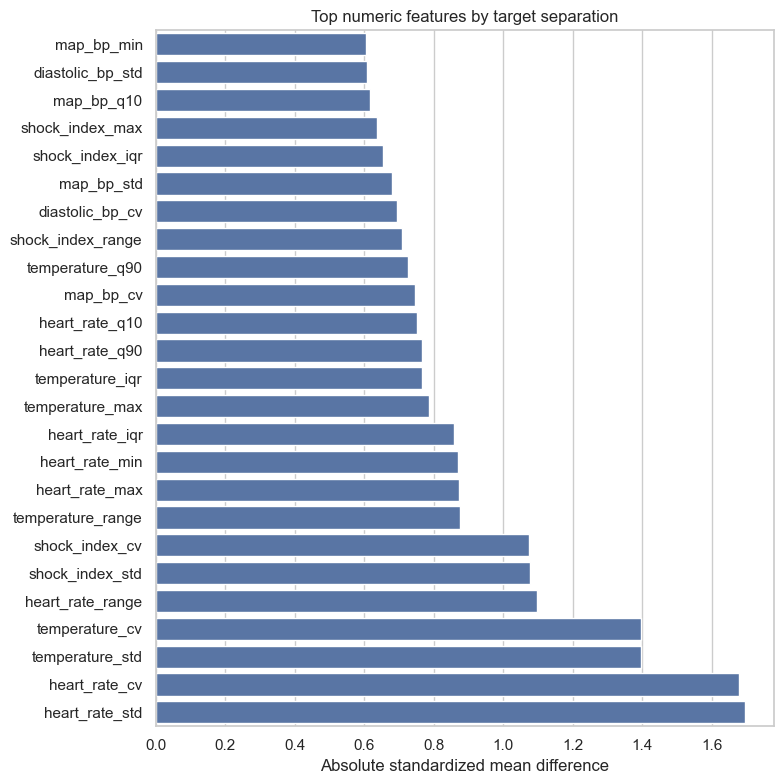

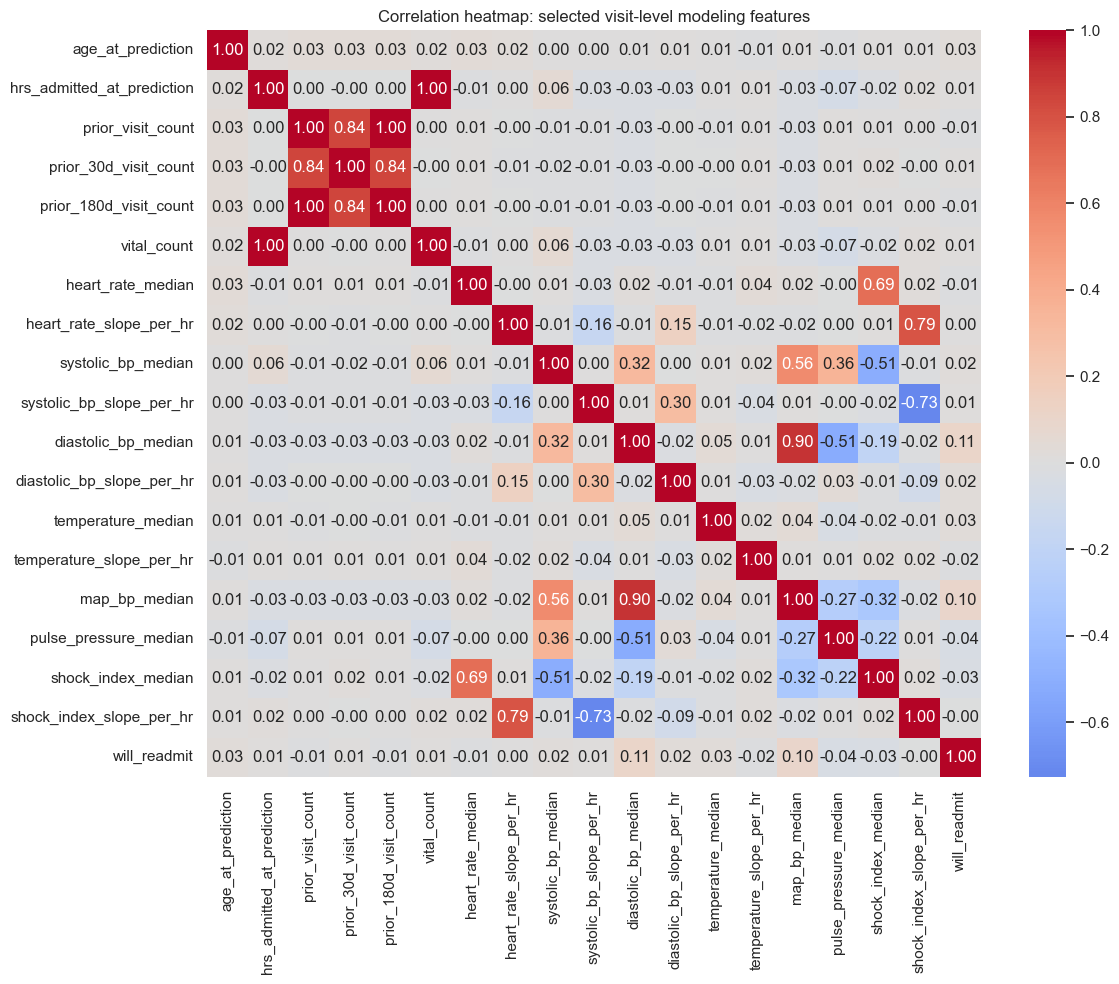

Highly correlated feature pairs:


,feature_1,feature_2,abs_corr
36,prior_visit_count,prior_180d_visit_count,1.000000
21,hrs_admitted_at_prediction,vital_count,0.998342
138,diastolic_bp_median,map_bp_median,0.898145
35,prior_visit_count,prior_30d_visit_count,0.844916
51,prior_30d_visit_count,prior_180d_visit_count,0.844916
114,heart_rate_slope_per_hr,shock_index_slope_per_hr,0.787923
133,systolic_bp_slope_per_hr,shock_index_slope_per_hr,0.726358
102,heart_rate_median,shock_index_median,0.688546
121,systolic_bp_median,map_bp_median,0.563666
139,diastolic_bp_median,pulse_pressure_median,0.513454


In [18]:
# ---------------------------------------------------------------------
# 7. Rank numeric features by target separation
# ---------------------------------------------------------------------
# Uses standardized mean difference as a quick EDA signal.

numeric_cols = eda.select_dtypes(include=["number", "bool"]).columns.tolist()

exclude_from_eda = {
    label_col,
    "target",
    "died",
    "died_flag",
    "eligible",
    "eligible_for_first_6am_score",
}

numeric_cols = [
    col for col in numeric_cols
    if col not in exclude_from_eda
]

rows = []

for col in numeric_cols:
    group0 = eda.loc[eda[label_col] == 0, col].dropna()
    group1 = eda.loc[eda[label_col] == 1, col].dropna()

    if len(group0) == 0 or len(group1) == 0:
        continue

    pooled_std = np.sqrt((group0.var() + group1.var()) / 2)

    if pooled_std == 0 or np.isnan(pooled_std):
        smd = np.nan
    else:
        smd = (group1.mean() - group0.mean()) / pooled_std

    rows.append({
        "feature": col,
        "no_readmit_mean": group0.mean(),
        "readmit_mean": group1.mean(),
        "mean_diff": group1.mean() - group0.mean(),
        "std_mean_diff": smd,
        "abs_std_mean_diff": abs(smd) if pd.notna(smd) else np.nan,
    })

smd_df = (
    pd.DataFrame(rows)
    .sort_values("abs_std_mean_diff", ascending=False)
    .reset_index(drop=True)
)

print("Top numeric features by standardized mean difference:")
display(smd_df.head(30))

plt.figure(figsize=(8, 8))
sns.barplot(
    data=smd_df.head(25).sort_values("abs_std_mean_diff"),
    x="abs_std_mean_diff",
    y="feature",
)
plt.title("Top numeric features by target separation")
plt.xlabel("Absolute standardized mean difference")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 8. Correlation heatmap for selected modeling features
# ---------------------------------------------------------------------

corr_features = [
    "age_at_prediction",
    "hrs_admitted_at_prediction",
    "prior_visit_count",
    "prior_30d_visit_count",
    "prior_180d_visit_count",
    "vital_count",
    "heart_rate_median",
    "heart_rate_slope_per_hr",
    "systolic_bp_median",
    "systolic_bp_slope_per_hr",
    "diastolic_bp_median",
    "diastolic_bp_slope_per_hr",
    "temperature_median",
    "temperature_slope_per_hr",
    "map_bp_median",
    "pulse_pressure_median",
    "shock_index_median",
    "shock_index_slope_per_hr",
    label_col,
]

corr_features = [col for col in corr_features if col in eda.columns]

corr = eda[corr_features].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
)
plt.title("Correlation heatmap: selected visit-level modeling features")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 9. Optional: inspect highly correlated feature pairs
# ---------------------------------------------------------------------

corr_abs = corr.abs().where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    corr_abs
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)

print("Highly correlated feature pairs:")
display(high_corr_pairs.head(25))

### Feature Correlation and Target Separation Summary

Correlation analysis showed several expected relationships among engineered features. Some features were nearly redundant, including `prior_visit_count` and `prior_180d_visit_count`, as well as `hrs_admitted_at_prediction` and `vital_count`. These relationships suggest that some features may carry overlapping information and could be removed or handled during feature selection to simplify the final production model.

Several derived vital sign features were also correlated by design. For example, MAP was strongly correlated with diastolic blood pressure, and shock index was correlated with heart rate and systolic blood pressure. These relationships are clinically expected because MAP, pulse pressure, and shock index are calculated from the raw vital signs.

The standardized mean difference analysis showed that the strongest separation between readmitted and non-readmitted encounters came from vital sign variability features rather than simple median values. Heart rate variability (`heart_rate_std`, `heart_rate_cv`, and `heart_rate_range`) and temperature variability (`temperature_std`, `temperature_cv`, and `temperature_range`) showed the largest differences between outcome groups.

Readmitted patients tended to have lower heart rate variability but higher temperature variability compared with non-readmitted patients. Several shock index and MAP variability features also showed moderate target separation.

Overall, these findings suggest that visit-level physiologic variability may be more informative for readmission prediction than static demographic features or single vital sign measurements. The correlation results also support using feature selection or model-based importance methods to reduce redundant predictors before deployment.

## Clean up cohort for input to modeling experiments

In [19]:
# ---------------------------------------------------------------------
# Drop leakage, redundant, and highly correlated features before modeling
# ---------------------------------------------------------------------

cols_to_drop = [
    # Duplicate / target leakage risk
    "prev_target",
    "prior_readmits",

    # Raw timestamps / non-production model inputs
    "birth_date",
    "ed_arrival",
    "admission",
    "discharge",
    "score_time",
    "prediction_time",
    "first_vital_time",
    "last_vital_time",
    "prev_discharge",

    # Eligibility / outcome-definition artifacts
    "died",
    "died_flag",
    "eligible",
    "eligible_for_first_6am_score",

    # Redundant age features if using age_at_prediction
    "age_years",
    "age_group",
    "age_sq",

    # Older duplicated prior-history fields
    "prior_visits",
    "has_prior",
    "days_since_prev",
    "return30_flag",
    "return90_flag",

    # Highly correlated / redundant from EDA
    "prior_180d_visit_count",  # duplicate of prior_visit_count
    "vital_count",            # nearly identical to hrs_admitted_at_prediction

    # Operational/data-quality artifacts, less clinically meaningful
    "bp_swapped_rate",
    "temp_F_rate",
    "heart_rate_oob",
    "systolic_bp_oob",
    "diastolic_bp_oob",
    "temperature_oob",
    "hr_oob_rate",
    "sbp_oob_rate",
    "dbp_oob_rate",
    "temp_oob_rate",

    # # Optional: operational duration features if you want a cleaner vitals model
    # "hours_observed",
    # "obs_density",
]

cohort = cohort.drop(columns=[c for c in cols_to_drop if c in cohort.columns])

In [20]:
print(list(cohort.columns))

['first_name', 'last_name', 'sex', 'patient_id', 'visit_id', 'will_readmit', 'los_hours', 'ed_to_admit_hours', 'time_to_score_hours', 'age_at_prediction', 'target', 'arr_hour', 'arr_dow', 'arr_sin', 'arr_cos', 'arr_dow_sin', 'arr_dow_cos', 'adm_hour', 'adm_dow', 'adm_sin', 'adm_cos', 'adm_dow_sin', 'adm_dow_cos', 'admit_weekend', 'admit_night', 'hrs_admitted_at_prediction', 'hrs_from_ed_to_prediction', 'prior_visit_count', 'has_prior_visit', 'days_since_prev_discharge', 'prior_readmit_30d', 'history_prior_readmit_30d', 'prior_readmit_30d_count_before', 'prior_30d_visit_count', 'first_hr', 'last_hr', 'hours_observed', 'obs_density', 'hrs_since_last_vital_at_prediction', 'gap_mean', 'gap_median', 'gap_std', 'gap_max', 'heart_rate_first', 'heart_rate_last', 'heart_rate_mean', 'heart_rate_median', 'heart_rate_min', 'heart_rate_max', 'heart_rate_std', 'heart_rate_skew', 'heart_rate_q10', 'heart_rate_q25', 'heart_rate_q75', 'heart_rate_q90', 'heart_rate_range', 'heart_rate_iqr', 'heart_rate_

In [22]:
# ---------------------------------------------------------------------
# Save finalized cohort dataframe for modeling notebook
# ---------------------------------------------------------------------
output_path = (
    PROJECT_ROOT /
    f"model_input_{timestamp}.pkl"
)

# Pickle preserves datatypes and is lightweight for pandas workflows
cohort.to_pickle(output_path)

print(f"Saved modeling dataset to:\n{output_path}")
print(f"Shape: {cohort.shape}")

Saved modeling dataset to:
/Users/shelbysmatlock/Datascience/model_input_18052026.pkl
Shape: (5297, 184)
